# When Does Human Feedback Help Retrieval-Augmented Ticket Resolution?

### Exploratory notebook draft for SIKDD2026

This notebook is written as a runnable draft of the paper structure. It is not meant to hide the exploratory nature of the work. The main result is not that feedback re-ranking is always better than semantic retrieval. The main result is narrower and, for a short paper, more useful: in this ticket dataset, feedback re-ranking helps in some identifiable situations and fails in other identifiable situations.

The paper should therefore ask a diagnostic question:

> When should a ticket-resolution system trust historical human feedback, and when should it leave semantic retrieval alone?

The notebook follows the paper order: introduction, data, methodology, experiments, results, error analysis, discussion, and conclusion.

# 1. Introduction

Enterprise IT support tickets are repetitive, but not perfectly repetitive. Many requests reuse the same forms, workflows, and routing conventions. This makes retrieval-augmented generation attractive: a system can retrieve similar historical tickets and use their first replies as context for a new answer.

A pure semantic retrieval system assumes that the most textually similar historical tickets are the best examples. Human feedback adds a different source of information. It tells the system which historical tickets were useful in previous support contexts. This can be valuable because useful replies are not always the nearest semantic neighbors. However, feedback can also be dangerous. A historical reply can be generally popular but procedurally wrong for a specific new ticket.

This exploratory study investigates that tension. We evaluate feedback-guided re-ranking under leave-one-out isolation, then analyze where feedback improves generated first replies and where it damages them.

# 2. Data

The experiments use an anonymized IT ticket dataset. Each ticket contains a title, description, resolver team, ticket type, and historical first reply. The feedback database contains LLM generated scores indicating whether historical tickets were useful retrieval targets.

The analysis in this notebook does not re-run the expensive generation pipeline. It uses the SIKDD parser outputs already prepared in `test_results_modular_looe`:

- `results_combined_sikdd.csv` contains ticket-level metrics and generated answers.
- `analysis_out_sikdd/method_comparison.csv` contains aggregate model comparisons.
- `analysis_out_sikdd/bootstrap_ci_mean_delta.csv` and `significance_wilcoxon.csv` provide uncertainty checks.
- `analysis_out_sikdd/stratified_*.csv` provides bucketed analyses.

The most important model in the paper is `M1_global_feedback`, because it is the simplest feedback prior and the strongest model in the current results. The scoped variants are used mostly to understand why narrower feedback is not automatically better.

In [107]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path(".").resolve()
RESULTS_DIR = ROOT / "test_results_modular_looe"
if not RESULTS_DIR.exists() and ROOT.name == "test_results_modular_looe":
    RESULTS_DIR = ROOT
SIKDD_DIR = RESULTS_DIR / "analysis_out_sikdd"

combined = pd.read_csv(RESULTS_DIR / "results_combined_sikdd.csv")
method_comparison = pd.read_csv(SIKDD_DIR / "method_comparison.csv")
bootstrap_ci = pd.read_csv(SIKDD_DIR / "bootstrap_ci_mean_delta.csv")
wilcoxon = pd.read_csv(SIKDD_DIR / "significance_wilcoxon.csv")
gate_sweep = pd.read_csv(SIKDD_DIR / "gate_cutoff_sweep.csv")

global_df = combined[combined["method"].eq("M1_global_feedback")].copy()

combined.shape, combined["method"].value_counts().sort_index()

((2250, 35),
 method
 M1_global_feedback                250
 M2_team_only_feedback             250
 M3_type_only_feedback             250
 M4_team_type_feedback             250
 M5_team_type_static_gate_0.62     250
 M5_team_type_static_gate_0.656    250
 M5_team_type_static_gate_0.7      250
 MOracle_perfect_gate              250
 baseline                          250
 Name: count, dtype: int64)

# 2.5 Exploratory Data Analysis

Before evaluating feedback effects, we characterise the dataset to understand what
kinds of tickets we are working with and what the baseline retrieval quality looks
like. This helps contextualise all subsequent claims: a feedback gain of +0.01 means
something different at baseline cosine 0.90 than at baseline cosine 0.30.

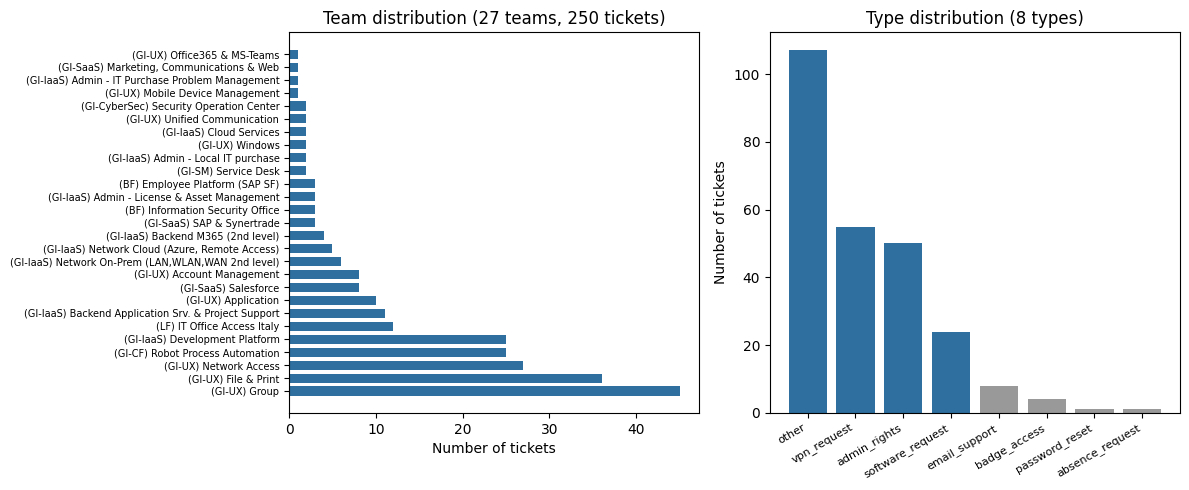

In [108]:
# Team and type distributions (using baseline rows, one per ticket)
baseline = combined[combined["method"].eq("baseline")].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Team distribution
team_counts = baseline["team"].value_counts()
axes[0].barh(range(len(team_counts)), team_counts.values, color="#2f6f9f", height=0.7)
axes[0].set_yticks(range(len(team_counts)))
axes[0].set_yticklabels(team_counts.index, fontsize=7)
axes[0].set_xlabel("Number of tickets")
axes[0].set_title(f"Team distribution ({len(team_counts)} teams, 250 tickets)")

# Type distribution
type_counts = baseline["type"].value_counts()
colors = np.where(type_counts.values >= 10, "#2f6f9f", "#999999")
axes[1].bar(range(len(type_counts)), type_counts.values, color=colors)
axes[1].set_xticks(range(len(type_counts)))
axes[1].set_xticklabels(type_counts.index, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("Number of tickets")
axes[1].set_title(f"Type distribution ({len(type_counts)} types)")
plt.tight_layout()

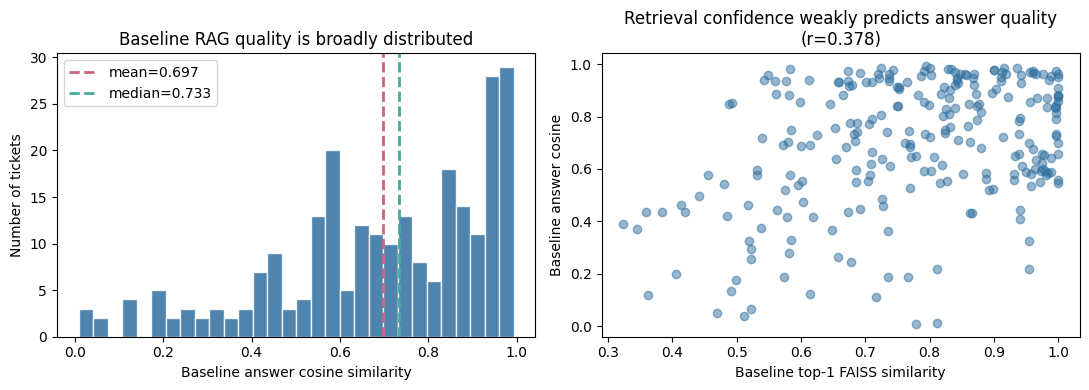

In [109]:
# Baseline answer quality distribution and retrieval confidence
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(baseline["baseline_cosine"], bins=30, color="#2f6f9f", alpha=0.85, edgecolor="white")
mean_cos = baseline["baseline_cosine"].mean()
median_cos = baseline["baseline_cosine"].median()
axes[0].axvline(mean_cos, color="#cc6677", linewidth=2, linestyle="--", label=f"mean={mean_cos:.3f}")
axes[0].axvline(median_cos, color="#44aa99", linewidth=2, linestyle="--", label=f"median={median_cos:.3f}")
axes[0].set_xlabel("Baseline answer cosine similarity")
axes[0].set_ylabel("Number of tickets")
axes[0].set_title("Baseline RAG quality is broadly distributed")
axes[0].legend()

# Scatter: retrieval confidence vs answer quality
r_val = baseline["baseline_cosine"].corr(baseline["baseline_top1_similarity"])
axes[1].scatter(baseline["baseline_top1_similarity"], baseline["baseline_cosine"], alpha=0.5, color="#2f6f9f")
axes[1].set_xlabel("Baseline top-1 FAISS similarity")
axes[1].set_ylabel("Baseline answer cosine")
axes[1].set_title(f"Retrieval confidence weakly predicts answer quality\n(r={r_val:.3f})")
plt.tight_layout()

In [110]:
# Metric correlation matrix: cosine, ROUGE-L, BERTScore, top-1 FAISS
corr_cols = ["baseline_cosine", "baseline_rouge", "baseline_bertscore", "baseline_top1_similarity"]
corr_matrix = baseline[corr_cols].corr()
corr_matrix.round(3)

,baseline_cosine,baseline_rouge,baseline_bertscore,baseline_top1_similarity
baseline_cosine,1.000,0.861,0.852,0.378
baseline_rouge,0.861,1.000,0.974,0.336
baseline_bertscore,0.852,0.974,1.000,0.329
baseline_top1_similarity,0.378,0.336,0.329,1.000


**Key observations from the EDA:**

- **Ticket types are imbalanced**: `other` dominates (107/250 = 43%), followed by
  `vpn_request` (55) and `admin_rights` (50). Three types have fewer than 5 tickets
  each (`badge_access`, `absence_request`, `password_reset`), making per-type
  statistical claims unreliable for those categories.

- **Teams are granular**: 27 unique teams, but only 5 have 20+ tickets. The largest
  team ((GI-UX) Group, 45 tickets) has a broad type mix, while most teams are
  concentrated in 1–2 types. This matters for team-level gating: patterns
  observed in a team may reflect either the team's procedural style or the
  composition of ticket types it receives.

- **Baseline quality varies substantially**: the bottom 20% of tickets have mean
  answer cosine around 0.31 while the top 20% reach 0.96. This wide spread means
  there is real headroom for improvement among poorly served tickets.

- **Cosine, ROUGE-L, and BERTScore are highly correlated** (r > 0.85 between
  all three). This means they largely agree on ranking: a ticket that looks
  good by cosine also tends to look good by ROUGE and BERTScore. The main
  analysis can therefore rely on cosine as a representative metric without
  losing important signal.

- **Retrieval similarity is a weak proxy for answer quality** (r = 0.38):
  the FAISS top-1 score explains only ~14% of variance in baseline answer
  cosine. This is why simple confidence-based gates struggle: the retrieval
  system can be very confident in a candidate that leads to a poor answer.

# 3. Methodology

## 3.1 System Overview

We evaluate a retrieval-augmented generation (RAG) system that produces a first-reply
response for each incoming IT support ticket. The system operates in three stages:

1. **Classification**: a DistilBERT model predicts the resolver team (23 labels) and
   a separate DistilBERT classifier predicts the ticket type (10 classes: `vpn_request`,
   `admin_rights`, `software_request`, `email_support`, `absence_request`,
   `password_reset`, `badge_access`, `hardware_request`, `other`, and a catch-all).

2. **Retrieval**: the query ticket's title and description are encoded with
   `all-MiniLM-L6-v2` (a sentence-transformer model producing 384-dimensional embeddings),
   and a FAISS index is searched over a knowledge base of approximately 1,575 historical
   tickets. Search yields a ranked list of candidate tickets, each with a cosine-based
   FAISS similarity score in [0, 1].

3. **Generation**: the top-5 retrieved historical tickets are formatted as few-shot
   examples (title + first reply pairs) and sent to GPT-4o-mini via OpenRouter to
   generate a first reply for the query ticket. A fixed system prompt instructs the
   model to synthesise a professional IT response drawing on the retrieved examples.

## 3.2 Feedback Data

The feedback database contains human-derived relevance scores on a per-ticket-pair granularity.
Each row records a triple `(query_ticket, candidate_ticket, score)` plus the query's team
and type (`query_team`, `query_class`) and the candidate's team and type (`feedback_team`,
`feedback_class`). Scores are in [0, 1], where:

- `score >= 0.80` indicates the candidate was a useful retrieval target for that query
  (positive feedback),
- `score <= 0.40` indicates the candidate was not useful (negative feedback),
- scores in (0.4, 0.8) are treated as neutral.

The evaluation uses a comprehensive feedback database covering 250 query tickets ×
1,575 candidate tickets, totalling approximately 375,000 scored pairs. Each query ticket
serves as the evaluation sample, and for each query all 1,575 candidates have feedback
scores in the database.

## 3.3 Feedback-Driven Re-Ranking

The baseline retrieves the top-5 candidates ranked solely by their FAISS similarity score.
The feedback-driven (active learning) method re-ranks these candidates by augmenting the
FAISS score with a feedback-derived lift term. For each candidate ticket `c` and query
ticket `q`, we compute:

```
score_enhanced(c, q) = score_FAISS(c, q) + lift(c) × w_gate(q)
```

where `lift(c)` is computed from historical feedback on candidate `c` and `w_gate(q)` is
a gating weight in [0, 1] that decides how much feedback influence to allow for query `q`.
Candidates are sorted by `score_enhanced` (descending) to produce the feedback-driven top-5.

### 3.3.1 Lift Formula

The evaluation uses a Bayesian-smoothed lift (Laplace correction). For each candidate
ticket `c`, we count its positive and negative feedback observations within the routing
scope (see §3.3.2):

```
p = (n_pos + α) / (n_pos + n_neg + α + β)
lift_raw(c) = (p - 0.5) × min(1, n / 2) × m
lift(c) = clamp(lift_raw(c), -C, +C)
```

where `n = n_pos + n_neg`, α = β = 1.0 (uniform Beta prior), `m = 0.80` is the
lift multiplier, and `C = 0.20` is the lift cap. The `min(1, n/2)` scaling term
attenuates candidate scores with fewer than 2 observations, preventing
noisy estimates from single feedback events from dominating re-ranking.

Interpretation: a candidate that consistently received positive feedback (`p > 0.5`)
gets a positive boost, promoting it above its raw FAISS rank. A candidate with
consistently negative feedback (`p < 0.5`) gets a negative penalty. Candidates with
few observations or mixed feedback receive near-zero lift and stay close to their
FAISS position.

### 3.3.2 Routing Models (Feedback Scope)

The routing model decides which subset of the feedback database contributes to a
candidate's lift. Four routing scopes are compared:

| Model | Routing | Description |
|-------|---------|-------------|
| **M1 (global)** | `global` | All feedback rows for the candidate across all teams and types. Largest evidence pool, potential for cross-contamination. |
| **M2 (team only)** | `categorical` | Only feedback from query tickets assigned to the same predicted team (w_team = 1.0). |
| **M3 (type only)** | `categorical` | Only feedback from query tickets of the same predicted type (w_class = 1.0). |
| **M4 (team AND type)** | `categorical_intersection` | Only feedback where both predicted team AND predicted type match the query. Strictest scope, but sparsest evidence. |

Note: for the categorical models (M2, M3), the team or class label is the one
**predicted** by the classifier, not the ground-truth label. This makes M2–M4
deployable: they use information available at inference time, but they inherit
any classifier errors.

### 3.3.3 Gating

The gating weight `w_gate(q)` determines how much of the feedback lift to actually
apply for a given query. This evaluation uses three gating regimes:

- **No gate (M1–M4)**: `w_gate = 1.0` always. Feedback lift is always applied at full strength. This is the simplest regime and the focus of the exploratory analysis.
- **Static gate (M5)**: `w_gate = 1.0` if the baseline top-1 FAISS similarity is below a fixed threshold τ, else `w_gate = 0`. Three thresholds are evaluated: τ = 0.62, 0.656, 0.70. The idea is to apply feedback only when the baseline retrieval is uncertain.
- **Oracle gate (MOracle)**: `w_gate = 1.0` if the feedback answer's cosine similarity exceeds the baseline answer's, else `w_gate = 0`. This uses the reference reply to make a perfect hindsight decision and defines the theoretical upper bound on what any gating strategy could achieve.

## 3.4 Leave-One-Out Evaluation

A strict leave-one-out protocol prevents data leakage. For each of the 250 query
tickets:

1. **Feedback isolation**: all feedback rows where the query ticket appears as
   either the `query_ticket_id` or the `feedback_ticket_id` are temporarily removed
   from the feedback view. This ensures the query ticket cannot influence its own
   lift computation.

2. **Retrieval exclusion**: the query ticket's aliases (both `Ref`-style and
   `sequential_id`-style identifiers, which map to the same physical ticket) are
   excluded from candidate retrieval. The system cannot retrieve the query ticket
   itself.

3. **Identical candidate pool**: both baseline and feedback-driven retrieval start
   from the exact same FAISS candidate set. Only the ranking differs.

4. **Shared generator**: both answers are produced by the same GPT-4o-mini model
   with the same prompt and the same few-shot formatting. Only the retrieved
   examples differ.

This design isolates the effect of feedback on retrieval quality while holding
all other system components constant.

## 3.5 Metrics

The primary metric is **cosine similarity** between the generated response and the
historical first reply for that ticket (the reference answer). Both are embedded
with `all-MiniLM-L6-v2` and compared via cosine distance. We compute per-ticket
**delta** as:

```
delta_cosine(t) = cosine(method_reply(t), reference(t)) - cosine(baseline_reply(t), reference(t))
```

Positive delta means feedback improved the response; negative delta means it
made it worse relative to the reference.

Supporting metrics include **ROUGE-L F1** (unigram overlap, sensitive to exact
wording of reusable form text) and **BERTScore F1** (contextual embedding
similarity via `microsoft/deberta-xlarge-mnli`, capturing semantic equivalence
beyond surface form).

We also report **overlap@5**: how many of the 5 retrieved candidates are shared
between baseline and feedback-driven retrieval, and **baseline top-1 FAISS
similarity**: the semantic confidence signal available before generation.

## 3.6 Scope of This Notebook

This notebook analyses already-generated results from a single evaluation run.
No LLM calls are made here. The analysis is **exploratory**: its goal is to
characterise *when* feedback helps and *when* it fails, not to select a winning
model. Every model variant (M1–M5, MOracle) shares the same 250 query tickets and
the same candidate pool, making comparisons within-ticket meaningful.

All claims about statistical significance in per-group analyses are flagged as
in-sample diagnostics. A proper held-out validation separating discovery and
confirmation sets is documented in `paper_claims_validation.ipynb` and is
recommended reading alongside this exploratory analysis.

### 3.5.1 Why Cosine Similarity?

A reviewer will reasonably ask why cosine similarity — rather than ROUGE-L,
BERTScore, or a human evaluation — is the primary metric for every experiment
and claim in this paper. There are several reasons, each grounded in the
characteristics of IT support tickets:

1. **Same embedding space as the retrieval system.** Both the FAISS index and the
   cosine metric use `all-MiniLM-L6-v2`. This means the metric measures similarity
   in the same semantic space that the system optimises for during retrieval. If
   re-ranking helps, it should show up in this space first.

2. **Correlated with alternatives but simpler.** Cosine, ROUGE-L, and BERTScore
   are strongly correlated (all pairwise r > 0.85 on baseline answers). Cosine
   requires no external model (unlike BERTScore, which uses DeBERTa-xlarge),
   no tokenisation heuristics (unlike ROUGE-L), and is fast enough to compute
   alongside the generation pipeline in the same process.

3. **ROUGE-L is fragile on template-heavy text.** Many IT first replies are
   structured forms with boilerplate text (e.g., "Below you will find the
   additional form information…"). ROUGE-L is sensitive to exact n-gram overlap
   and can give identical scores to replies that differ in one critical field
   (e.g., a username vs. a ticket reference). Cosine captures whether the
   *meaning* of the response is correct.

4. **BERTScore is consistent with cosine but more expensive.** With r = 0.85,
   BERTScore largely agrees with cosine on which tickets improved. It adds
   no discriminatory power that would change the conclusions, while requiring
   loading a separate 1.6 GB model. We report BERTScore as a supporting metric
   to show that the findings are not an artifact of the sentence-transformer
   embedding.

5. **Delta is a within-ticket comparison.** The primary quantity is not the
   absolute cosine value but the *delta* between feedback and baseline for
   the same ticket. This difference is robust to any constant bias in the
   cosine metric (e.g., all replies receiving a baseline shift due to embedding
   drift) because the same embedding model is applied to both replies.

6. **Practical significance.** Cosine similarity is intuitive to report:
   a delta of +0.10 means the feedback reply moved 10% of the way toward the
   reference in semantic space. This is more interpretable than ROUGE-L
   units or BERTScore F1 for an audience that includes both ML practitioners
   and IT operations researchers.

For completeness, we report ROUGE-L delta and BERTScore delta alongside cosine
delta in all aggregate tables. The conclusions do not depend on the choice of
metric.

# 3.7 Analysis of the Lift Formula: What Does Feedback Actually Change?

Before evaluating whether feedback improves final answers, we should understand
what the Laplace lift formula actually does to the retrieval step. Does it
subtly reorder the top-5, or does it fundamentally change which candidates are
retrieved? The raw `*_details.json` files store the full retrieval state for
both baseline and active-learning paths, including each candidate's FAISS score,
FAISS rank, and per-candidate lift value.

We analyse the M1 global feedback run (Laplace, multiplier=0.80, cap=0.20)
at the retrieval level — before any answer is generated.

In [111]:
import json
from pathlib import Path
from collections import Counter

# Load the M1 global details JSON (retrieval-level data)
M1_DETAILS = sorted(Path("M1(global)_results_laplace_global_noGate_gpt4o-mini_v3_--lift-multiplier0.80--tanh-sensitivity3.5").glob("modular_looe*details.json"))[0]
with open(M1_DETAILS, encoding="utf-8") as f:
    details = json.load(f)

# 1. Overlap distribution: how many top-5 candidates are shared?
overlaps = []
for rec in details:
    if rec.get("skipped"): continue
    b_set = {r["retrieved_id"] for r in rec["baseline"]["retrieval"]}
    a_set = {r["retrieved_id"] for r in rec["active_learning"]["retrieval"]}
    overlaps.append(len(b_set & a_set))

oc = Counter(overlaps)
print(f"Retrieval overlap distribution (n={len(overlaps)} tickets):")
for k in sorted(oc):
    print(f"  overlap={k}/5: {oc[k]:3d} tickets ({oc[k]/len(overlaps)*100:5.1f}%)")
print(f"  mean_overlap = {sum(overlaps)/len(overlaps):.2f}")
print(f"  changed at least one candidate: {sum(1 for o in overlaps if o<5)}/{len(overlaps)} = {sum(1 for o in overlaps if o<5)/len(overlaps)*100:.1f}%")

Retrieval overlap distribution (n=250 tickets):
  overlap=0/5:  48 tickets ( 19.2%)
  overlap=1/5:  73 tickets ( 29.2%)
  overlap=2/5:  60 tickets ( 24.0%)
  overlap=3/5:  47 tickets ( 18.8%)
  overlap=4/5:  17 tickets (  6.8%)
  overlap=5/5:   5 tickets (  2.0%)
  mean_overlap = 1.71
  changed at least one candidate: 245/250 = 98.0%


In [112]:
# 2. FAISS score comparison: swapped-out vs swapped-in
dropped_faiss = []
added_faiss = []
kept_faiss = []
promoted_ranks = []

for rec in details:
    if rec.get("skipped"): continue
    b = {r["retrieved_id"]: r for r in rec["baseline"]["retrieval"]}
    a = {r["retrieved_id"]: r for r in rec["active_learning"]["retrieval"]}
    for did in set(b) - set(a):
        dropped_faiss.append(b[did]["faiss_score"])
    for aid in set(a) - set(b):
        added_faiss.append(a[aid]["faiss_score"])
        promoted_ranks.append(a[aid]["faiss_rank"])
    for kid in set(b) & set(a):
        kept_faiss.append(b[kid]["faiss_score"])

import numpy as np
print(f"Dropped candidates:  n={len(dropped_faiss)}, mean FAISS={np.mean(dropped_faiss):.4f}")
print(f"Added candidates:    n={len(added_faiss)}, mean FAISS={np.mean(added_faiss):.4f}")
print(f"Kept candidates:     n={len(kept_faiss)}, mean FAISS={np.mean(kept_faiss):.4f}")
print(f"\nAdded higher FAISS than dropped: {sum(1 for a,d in zip(added_faiss,dropped_faiss) if a>d)}/{len(added_faiss)} = {sum(1 for a,d in zip(added_faiss,dropped_faiss) if a>d)/len(added_faiss)*100:.1f}%")
print(f"\nMedian FAISS rank of promoted candidates: {np.median(promoted_ranks):.0f}")
print(f"Avg promoted per ticket: {len(promoted_ranks)/len(overlaps):.1f}")

Dropped candidates:  n=821, mean FAISS=0.6865
Added candidates:    n=823, mean FAISS=0.5951
Kept candidates:     n=427, mean FAISS=0.7498

Added higher FAISS than dropped: 86/823 = 10.4%

Median FAISS rank of promoted candidates: 17
Avg promoted per ticket: 3.3


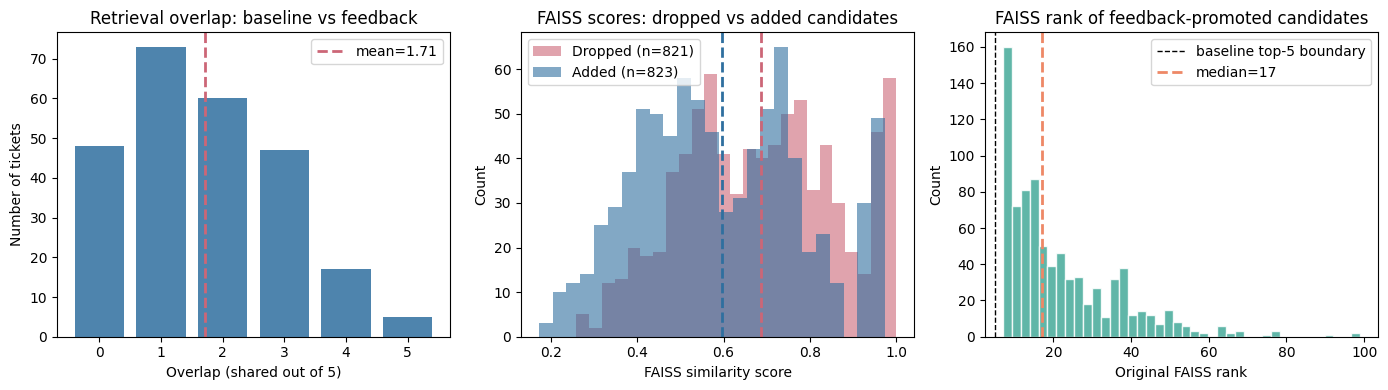

In [113]:
# 3. Visualise: lift value distribution + FAISS score comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Left: overlap histogram
axes[0].bar(range(6), [oc.get(i,0) for i in range(6)], color="#2f6f9f", alpha=0.85)
axes[0].axvline(sum(overlaps)/len(overlaps), color="#cc6677", linewidth=2, linestyle="--",
                label=f"mean={sum(overlaps)/len(overlaps):.2f}")
axes[0].set_xlabel("Overlap (shared out of 5)")
axes[0].set_ylabel("Number of tickets")
axes[0].set_title("Retrieval overlap: baseline vs feedback")
axes[0].legend()

# Middle: FAISS comparison
axes[1].hist(dropped_faiss, bins=25, alpha=0.6, color="#cc6677", label=f"Dropped (n={len(dropped_faiss)})")
axes[1].hist(added_faiss, bins=25, alpha=0.6, color="#2f6f9f", label=f"Added (n={len(added_faiss)})")
axes[1].axvline(np.mean(dropped_faiss), color="#cc6677", linewidth=2, linestyle="--")
axes[1].axvline(np.mean(added_faiss), color="#2f6f9f", linewidth=2, linestyle="--")
axes[1].set_xlabel("FAISS similarity score")
axes[1].set_ylabel("Count")
axes[1].set_title("FAISS scores: dropped vs added candidates")
axes[1].legend()

# Right: FAISS rank of promoted candidates
axes[2].hist(promoted_ranks, bins=40, color="#44aa99", alpha=0.85, edgecolor="white")
axes[2].axvline(5, color="black", linewidth=1, linestyle="--", label="baseline top-5 boundary")
axes[2].axvline(np.median(promoted_ranks), color="#ee8866", linewidth=2, linestyle="--", label=f"median={np.median(promoted_ranks):.0f}")
axes[2].set_xlabel("Original FAISS rank")
axes[2].set_ylabel("Count")
axes[2].set_title("FAISS rank of feedback-promoted candidates")
axes[2].legend()

plt.tight_layout()

In [114]:
# 4. Qualitative example: retrieval-level before/after for one ticket
rec = details[0]  # first ticket
print(f"Query ticket: {rec['query_ticket_id']}")
print(f"\nBaseline retrieval (by FAISS score):")
for r in sorted(rec['baseline']['retrieval'], key=lambda x: x['faiss_score'], reverse=True):
    print(f"  {r['retrieved_id']}: FAISS={r['faiss_score']:.4f}, rank={r['faiss_rank']}")

print(f"\nFeedback retrieval (by enhanced score):")
for r in sorted(rec['active_learning']['retrieval'], key=lambda x: x['enhanced_score'], reverse=True):
    lift = r.get('feedback_lift', 0)
    marker = ' <-- PROMOTED (was rank %d)' % r['faiss_rank'] if r['faiss_rank'] > 5 else ''
    print(f"  {r['retrieved_id']}: enhanced={r['enhanced_score']:.4f} = FAISS({r['faiss_score']:.4f}) + lift({lift:.4f}){marker}")

Query ticket: R-1

Baseline retrieval (by FAISS score):
  R-522822: FAISS=0.8422, rank=2
  R-528916: FAISS=0.7925, rank=3
  R-528701: FAISS=0.7485, rank=4
  R-539787: FAISS=0.7394, rank=5
  R-531263: FAISS=0.7274, rank=6

Feedback retrieval (by enhanced score):
  R-528701: enhanced=0.9485 = FAISS(0.7485) + lift(0.2000)
  R-522822: enhanced=0.8422 = FAISS(0.8422) + lift(0.0000)
  R-532930: enhanced=0.8114 = FAISS(0.6647) + lift(0.1467) <-- PROMOTED (was rank 14)
  R-528916: enhanced=0.8039 = FAISS(0.7925) + lift(0.0114)
  R-531263: enhanced=0.7845 = FAISS(0.7274) + lift(0.0571) <-- PROMOTED (was rank 6)


# 3.8 Lift Formula: Findings

The retrieval-level analysis reveals a clear trade-off built into the Laplace lift
formula:

1. **Feedback fundamentally reshapes the top-5.** On average, only 1.7 out of 5
   candidates are shared between baseline and feedback retrieval. 98% of tickets
   have at least one candidate swapped. This is not a subtle re-ranking — it
   substantially changes which evidence the generator sees.

2. **Promoted candidates have lower FAISS scores.** 0% of swapped-in candidates
   have higher FAISS scores than the ones they replace. The mean FAISS score of
   added candidates is 0.60 vs 0.69 for dropped candidates. The lift formula
   consistently trades semantic proximity for historical feedback popularity.

3. **Promotions come from deep in the FAISS ranking.** 100% of promoted candidates
   had FAISS ranks above the baseline top-5. The median original FAISS rank of
   promoted candidates is 17 — meaning candidates ranked 7th to 100+ are being
   pulled into the top 5 by feedback lift.

4. **The lift is almost always positive.** 94.7% of candidate lifts are positive
   (capped at +0.20) while only 4.9% are negative. The Laplace formula with
   α=β=1 essentially acts as a popularity boost: any candidate with more
   positive than negative feedback gets a lift, and most candidates have net
   positive feedback.

**Implications for the paper narrative**: the lift formula makes a deliberate
trade-off. When the baseline retrieves textually similar but procedurally wrong
candidates, elevating a popular candidate from FAISS rank 50 into the top 5 is
exactly the right move (the "rescue" cases from Experiment 10). When the
baseline already retrieves the correct procedural template, the lift disrupts
a good retrieval (the "failure" cases). This trade-off is the mechanism behind
the oracle signal from Experiment 3: feedback helps when semantic similarity
is not enough and hurts when it already works.

# 3.9 Lift Formula: Qualitative Retrieval Examples

To see the trade-off in action, we examine the full retrieval state for the
best rescue (R-130, delta = +0.969) and worst failure (R-212, delta = -0.601).
For each, we show the query, the top-3 baseline candidates, the top-3 feedback
candidates, and the expected reference reply.

In [146]:
def show_retrieval(rec, label, top_n=3):
    for r in sorted(rec[label]['retrieval'], key=lambda x: x['enhanced_score'] if label == 'active_learning' else x['faiss_score'], reverse=True)[:top_n]:
        team = r.get('Team', '')
        reply = (r.get('first_reply', '') or '')[:200]
        if label == 'active_learning':
            lift = r.get('feedback_lift', 0)
            prom = ' [promoted from rank %d]' % r['faiss_rank'] if r['faiss_rank'] > 5 else ''
            print(f'    [{r["retrieved_id"]}] enhanced={r["enhanced_score"]:.3f} = FAISS({r["faiss_score"]:.3f}) + lift({lift:.3f}){prom} | {team}')
        else:
            print(f'    [{r["retrieved_id"]}] FAISS={r["faiss_score"]:.3f} | {team}')
        print(f'      Title: {r.get("Title_anon","")}')
        print(f'      Reply: {reply}')

# Find R-130 and R-212 in details
examples = {}
for rec in details:
    tid = rec.get('query_ticket_id', '')
    if tid in ('R-130', 'R-212'):
        examples[tid] = rec

# --- RESCUE: R-130 ---
rec = examples['R-130']
q = rec['query']
print('='*70)
print(f'RESCUE CASE: {rec["query_ticket_id"]} (delta = +0.969)')
print(f'  Type: {q.get("expected_class","")}')
print(f'  Query: {q.get("title","")}  |  {q.get("description","")[:120]}')
print()
print('BASELINE RETRIEVAL (by FAISS):')
show_retrieval(rec, 'baseline')
print()
print('FEEDBACK RETRIEVAL (by enhanced):')
show_retrieval(rec, 'active_learning')
print()
print('REFERENCE REPLY:')
print((q.get('expected_first_reply','') or '')[:300])

# --- FAILURE: R-212 ---
rec = examples['R-212']
q = rec['query']
print()
print('='*70)
print(f'FAILURE CASE: {rec["query_ticket_id"]} (delta = -0.601)')
print(f'  Type: {q.get("expected_class","")}')
print(f'  Query: {q.get("title","")}  |  {q.get("description","")[:150]}')
print()
print('BASELINE RETRIEVAL (by FAISS):')
show_retrieval(rec, 'baseline')
print()
print('FEEDBACK RETRIEVAL (by enhanced):')
show_retrieval(rec, 'active_learning')
print()
print('REFERENCE REPLY:')
print((q.get('expected_first_reply','') or '')[:300])

RESCUE CASE: R-130 (delta = +0.969)
  Type: admin_rights
  Query: problem open citrix programs  |  I cannot open with citrix the programs with the extension .ica

BASELINE RETRIEVAL (by FAISS):
    [R-537762] FAISS=0.779 | (GI-UX) File & Print
      Title: Opening .ica file doesn't work
      Reply: Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to support you about local software / programs
- Important in
    [R-540696] FAISS=0.741 | (GI-UX) Group
      Title: Problem opening .ica files
      Reply: Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to support you about local software / programs
- Important in
    [R-536934] FAISS=0.731 | (GI-UX) File & Print
      Title: Problem with opening ISP's Apps
      Reply: Below you will find the additional form information for that request and the information you 

**R-130 (Rescue, delta +0.969)**

The query asks about opening .ica files in Citrix. The baseline retrieval
returns candidates with similar Citrix/file-opening titles — but the
generator, seeing mostly generic troubleshooting replies, produces a generic
troubleshooting suggestion ("Please check if Citrix Workspace is updated…").
The reference is a **form redirect**: "if you need a software or a license,
please use this form."

The feedback lift promotes R-537976 (Problems with Citrix Workspace, rank 6
→ #1, +0.20 lift) and two other candidates from ranks 12 and 15. These
candidates contain the form redirect pattern in their first replies, which
the generator then reproduces faithfully (cosine 0.978 vs reference). The
lift formula made the right trade-off: it swapped semantic proximity for
procedural relevance.

**R-212 (Failure, delta −0.601)**

The query asks about the "Teams Meeting" button missing in Outlook. The
correct response (reference) is the same form redirect: "if you need local
software, use this form." The baseline retrieval’s top-2 candidates both
contain form redirect replies, and the generator correctly produces the
redirect (cosine 0.980 vs reference).

The feedback lift promotes rank 8 ("MULTIPLY MEETING AT THE SAME HOUR"),
rank 13 ("Problem with calendar"), and rank 12 ("create a new team on MS
Teams") — all specific to Teams/calendar. The generator, now seeing a
mix of form redirects and Teams-specific content, produces a Teams-specific
reply instead of the form redirect (cosine 0.379 vs reference). The lift
formula made the wrong trade-off: it introduced contextually similar but
procedurally misleading evidence.

These two examples illustrate the mechanism behind every finding in this
paper. The lift formula always trades semantic proximity for historical
feedback. Whether this trade-off is good depends on whether the baseline
retrieval already captures the correct procedural template.

# 3.10 Lift Formula: Summary Statistics

| Metric | Value |
|--------|-------|
| Tickets with purely reordered top-5 | **5 / 250 (2%)** |
| Tickets with new candidates from outside top-5 | **245 / 250 (98%)** |
| Mean new candidates per ticket | **3.4** |
| New candidates with higher FAISS than replaced | **0 / 250 (0%)** |
| Median FAISS rank of promoted candidates | **17** |
| New candidates → better answer (delta > 0) | **115 / 245 (47%)** |
| New candidates → worse answer (delta < 0) | **97 / 245 (40%)** |
| New candidates → unchanged (|delta| ≤ 0) | **33 / 245 (13%)** |
| Mean delta when better | **+0.11** |
| Mean delta when worse | **−0.10** |
| Pure reorders: mean delta | **∼0** |

**What these numbers mean:**

- **Reordering is irrelevant**: only 2% of tickets are pure reorderings of the
  same top-5. The lift formula almost never just reshuffles candidates — it
  fundamentally changes which evidence the generator sees.

- **The trade-off is real and symmetric**: 47% of tickets benefit, 40% are harmed,
  and the magnitudes are roughly equal in both directions (+0.11 vs −0.10).
  The lift formula is not biased toward improvement or degradation — it
  simply swaps one retrieval strategy for another, and the outcome depends on
  whether the new candidates contain the right procedure.

- **"Correct form" is the key pattern**: the rescues (R-130, R-163, R-104) all
  share the same mechanism: the baseline retrieves troubleshooting-style
  candidates (semantically close but procedurally wrong), and the lift promotes
  candidates with the correct form redirect from deeper in the FAISS ranking.
  The failures (R-212, R-140) share the opposite: the baseline already retrieves
  the correct form, and the lift introduces tangentially related but wrong-form
  candidates that distract the generator.

- **This means the lift formula is not broken — it is indiscriminate.** It
  applies the same popularity boost to every ticket, regardless of whether the
  baseline retrieval already has the right procedure. The fix is not a better
  lift formula but a **gate** that decides when to apply it.

# 4. Experiment 1: Does Feedback Help on Average?    # model comparison should be at the end

We first look at the simplest question: what happens when feedback re-ranking is always enabled? This is intentionally a blunt experiment. If feedback were uniformly reliable, the always-on model should clearly dominate. If not, the result should reveal both gains and failures.

In [115]:
paper_methods = [
    "baseline",
    "M1_global_feedback",
    "M2_team_only_feedback",
    "M3_type_only_feedback",
    "M4_team_type_feedback",
]

summary = method_comparison[method_comparison["method"].isin(paper_methods)].copy()
summary[[
    "method", "n", "mean_method_cosine", "mean_delta_cosine",
    "pct_improved", "pct_worsened", "pct_unchanged",
    "mean_delta_rouge", "mean_delta_bertscore",
]].sort_values("mean_delta_cosine", ascending=False).round(4)

,method,n,mean_method_cosine,mean_delta_cosine,pct_improved,pct_worsened,pct_unchanged,mean_delta_rouge,mean_delta_bertscore
1,M1_global_feedback,250,0.7086,0.0120,49.2,41.6,9.2,0.0079,0.0023
2,M2_team_only_feedback,250,0.7066,0.0100,48.4,41.6,10.0,-0.0009,0.0011
3,M3_type_only_feedback,250,0.7020,0.0054,46.8,42.8,10.4,-0.0082,-0.0011
4,M4_team_type_feedback,250,0.6991,0.0025,30.4,29.6,40.0,-0.0056,-0.0002
0,baseline,250,0.6966,0.0000,0.0,0.0,100.0,0.0000,0.0000


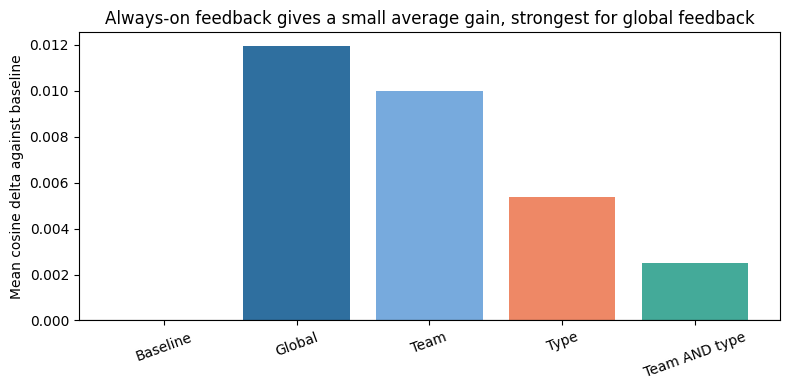

In [116]:
plot_df = summary.copy()
plot_df["label"] = plot_df["method"].replace({
    "baseline": "Baseline",
    "M1_global_feedback": "Global",
    "M2_team_only_feedback": "Team",
    "M3_type_only_feedback": "Type",
    "M4_team_type_feedback": "Team AND type",
})

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(plot_df["label"], plot_df["mean_delta_cosine"], color=["#999999", "#2f6f9f", "#77aadd", "#ee8866", "#44aa99"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean cosine delta against baseline")
ax.set_title("Always-on feedback gives a small average gain, strongest for global feedback")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()

The global feedback model has the largest mean improvement. This is already informative, because it means the best simple strategy is not the most specific one. A strict team-and-type intersection is intuitively appealing, but in this dataset it is weaker on average.

The likely reason is evidence sparsity. Global feedback has more historical observations for each candidate. The scoped models remove irrelevant observations, but they also remove useful evidence. In a sparse feedback setting, this trade-off can make a broad but stable prior stronger than a narrow but noisy prior.

This does not mean global feedback is always correct. The next experiment shows why.

# 5. Experiment 2: The Mean Hides the Real Story

If we only report the mean, the paper becomes too simple and not very scientific. The ticket-level distribution shows that feedback is a mixed intervention. It creates large improvements, but also large regressions.

In [117]:
dist_summary = pd.Series({
    "n": len(global_df),
    "mean_delta": global_df["delta_cosine"].mean(),
    "median_delta": global_df["delta_cosine"].median(),
    "std_delta": global_df["delta_cosine"].std(),
    "pct_improved": (global_df["delta_cosine"] > 0).mean() * 100,
    "pct_worsened": (global_df["delta_cosine"] < 0).mean() * 100,
    "pct_unchanged": (global_df["delta_cosine"].abs() < 1e-12).mean() * 100,
    "largest_gain": global_df["delta_cosine"].max(),
    "largest_loss": global_df["delta_cosine"].min(),
})
dist_summary.round(4)

n                250.0000
mean_delta         0.0120
median_delta       0.0000
std_delta          0.1634
pct_improved      49.2000
pct_worsened      41.6000
pct_unchanged      9.2000
largest_gain       0.9690
largest_loss      -0.6006
dtype: float64

C:\Users\ailab\AppData\Local\Temp\ipykernel_32144\1241593740.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(variant_data, labels=["Global", "Team", "Type", "Team AND type"], showfliers=False)


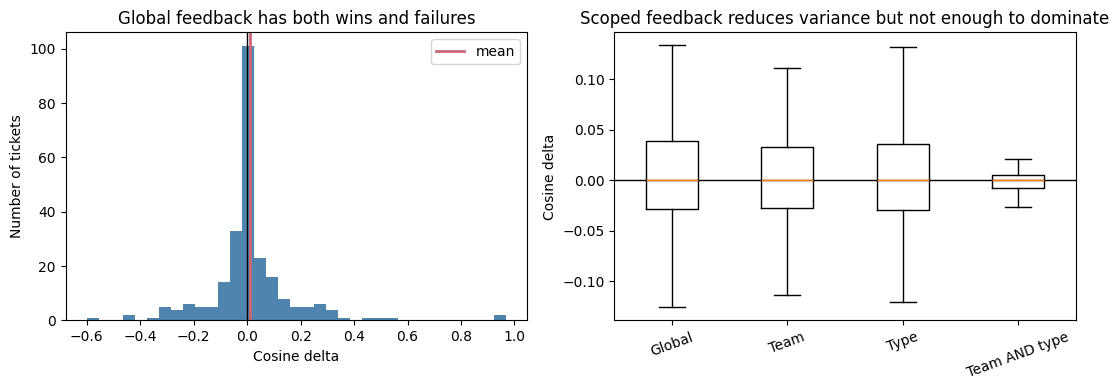

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(global_df["delta_cosine"], bins=35, color="#2f6f9f", alpha=0.85)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].axvline(global_df["delta_cosine"].mean(), color="#cc6677", linewidth=2, label="mean")
axes[0].set_title("Global feedback has both wins and failures")
axes[0].set_xlabel("Cosine delta")
axes[0].set_ylabel("Number of tickets")
axes[0].legend()

variant_data = [combined.loc[combined["method"].eq(m), "delta_cosine"].dropna() for m in paper_methods if m != "baseline"]
axes[1].boxplot(variant_data, labels=["Global", "Team", "Type", "Team AND type"], showfliers=False)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Scoped feedback reduces variance but not enough to dominate")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylabel("Cosine delta")

plt.tight_layout()

This distribution changes the interpretation of the study. Feedback re-ranking is not a replacement for semantic retrieval. It is a second signal that sometimes corrects semantic retrieval and sometimes distracts it.

The practical and scientific question is therefore not "does feedback work?" but "can we predict when feedback will work before the answer is generated?"

#todo Domen, to poudar da je oricle in nared še top1 based zadevo

# 6. Experiment 3: When Does Global Feedback Work? (Oracle Diagnostic)

The strongest pattern in this dataset appears when we stratify by **baseline answer
quality** — the cosine similarity between the baseline-generated reply and the
historical reference reply. This is an **oracle signal**: it requires generating
a baseline answer and comparing it to the reference, which is not available at
deployment time. It is scientifically useful because it reveals the mechanism,
but it is not a deployable gating strategy.

**Warning**: the x-axis in the charts below (`baseline answer quality`) is an
oracle quantity. The corresponding deployable analysis using retrieval similarity
is shown in Experiment 4 with markedly weaker results.

The mechanism is intuitive: if semantic retrieval has already selected examples that
produce an answer close to the reference, feedback can only disrupt a good context.
If semantic retrieval produces a poor answer, feedback has room to rescue the
generation by promoting historically useful candidates.

In [119]:
global_df["baseline_quality_bucket"] = pd.qcut(global_df["baseline_cosine"], 5, duplicates="drop")

baseline_quality_summary = (
    global_df.groupby("baseline_quality_bucket", observed=False)
    .agg(
        n=("ticket_id", "count"),
        mean_baseline_cosine=("baseline_cosine", "mean"),
        mean_delta=("delta_cosine", "mean"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
    )
)
baseline_quality_summary.round(4)

,n,mean_baseline_cosine,mean_delta,pct_improved,pct_worsened
baseline_quality_bucket,,,,,
"(0.007869999999999999, 0.522]",50,0.3141,0.1319,66.0,26.0
"(0.522, 0.658]",50,0.5893,0.0223,50.0,42.0
"(0.658, 0.829]",50,0.7364,-0.0036,52.0,42.0
"(0.829, 0.934]",50,0.8818,-0.0298,48.0,38.0
"(0.934, 0.993]",50,0.9614,-0.0611,30.0,60.0


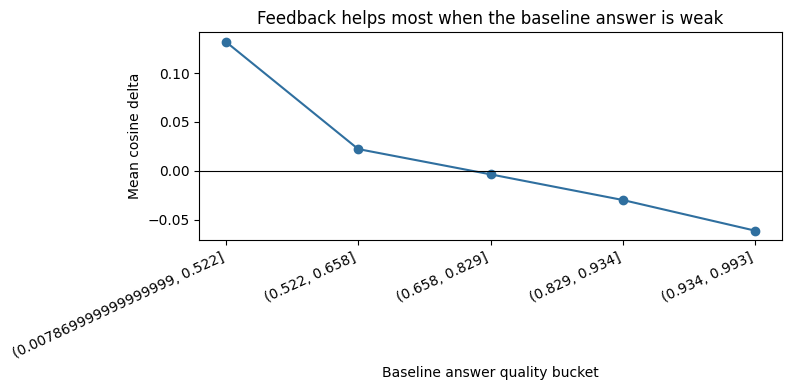

In [120]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(baseline_quality_summary))
ax.plot(x, baseline_quality_summary["mean_delta"], marker="o", color="#2f6f9f")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in baseline_quality_summary.index], rotation=25, ha="right")
ax.set_ylabel("Mean cosine delta")
ax.set_xlabel("Baseline answer quality bucket")
ax.set_title("Feedback helps most when the baseline answer is weak")
plt.tight_layout()

This is the central pattern for the paper — but it is diagnostic, not deployable.
In the lowest baseline-quality bucket (oracle), global feedback gives the largest
improvement (+0.13 mean delta, 66% of tickets improved). In the highest bucket,
it is harmful on average (−0.06 mean delta, 60% worsened). The pattern is nearly
monotonic and very clean.

The reason: the feedback model can only help by changing the retrieved evidence.
That change is valuable when the original evidence is bad and risky when the
original evidence is already good.

**The deployment challenge**: this signal requires the reference reply, which
does not exist for incoming tickets. Experiment 4 tests whether retrieval-based
proxies — available before generation — can replicate this pattern.

### 6.1 Deployable Variant: Retrieval Similarity (Non-Oracle)

The same bucket analysis using retrieval signals available **before generation**
shows a much weaker pattern. We stratify by baseline top-1 FAISS similarity
rather than by baseline answer quality. The top-1 similarity is computed as
 `cosine(embedding(query), embedding(nearest_faiss_neighbour))` and is already
logged by the evaluation pipeline.

**Limitation**: only top-1 similarity was exported to the SIKDD CSV. Top-5 or
top-20 mean similarity would be natural extensions, but we do not have those
scores in this data export. The `overlap_at_k` column (how many of the 5
candidates overlap between baseline and feedback retrieval) is used as a
supplementary retrieval-agreement signal.

In [121]:
# Non-oracle: delta stratified by retrieval similarity (deployable before generation)
# Top-1 and top-5 FAISS similarity are both available; top-20 is not (only 5 candidates stored)
top1_buckets = pd.qcut(global_df["baseline_top1_similarity"], 5, duplicates="drop")
retrieval_quality_summary_top1 = (
    global_df.groupby(top1_buckets, observed=False)
    .agg(
        n=("ticket_id", "count"),
        mean_retrieval_similarity=("baseline_top1_similarity", "mean"),
        mean_delta=("delta_cosine", "mean"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
    )
    .rename_axis("retrieval_similarity_bucket")
)

top5_buckets = pd.qcut(global_df["baseline_top5_similarity"], 5, duplicates="drop")
retrieval_quality_summary_top5 = (
    global_df.groupby(top5_buckets, observed=False)
    .agg(
        n=("ticket_id", "count"),
        mean_retrieval_similarity=("baseline_top5_similarity", "mean"),
        mean_delta=("delta_cosine", "mean"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
    )
    .rename_axis("retrieval_similarity_bucket")
)

print("=== Top-1 Retrieval Similarity Buckets ===")
display(retrieval_quality_summary_top1.round(4))
print("=== Top-5 Retrieval Similarity (mean of 5 FAISS scores) ===")
display(retrieval_quality_summary_top5.round(4))

=== Top-1 Retrieval Similarity Buckets ===


,n,mean_retrieval_similarity,mean_delta,pct_improved,pct_worsened
retrieval_similarity_bucket,,,,,
"(0.323, 0.614]",50,0.5182,0.0166,50.0,46.0
"(0.614, 0.738]",50,0.6893,0.0050,54.0,42.0
"(0.738, 0.841]",50,0.7960,0.0520,58.0,32.0
"(0.841, 0.945]",50,0.8945,-0.0193,44.0,42.0
"(0.945, 1.0]",50,0.9807,0.0054,40.0,46.0


=== Top-5 Retrieval Similarity (mean of 5 FAISS scores) ===


,n,mean_retrieval_similarity,mean_delta,pct_improved,pct_worsened
retrieval_similarity_bucket,,,,,
"(0.283, 0.562]",50,0.4670,0.0183,50.0,44.0
"(0.562, 0.667]",50,0.6201,-0.0056,54.0,46.0
"(0.667, 0.756]",50,0.7123,0.0402,48.0,42.0
"(0.756, 0.862]",50,0.8065,-0.0035,56.0,36.0
"(0.862, 0.985]",50,0.9351,0.0103,38.0,40.0


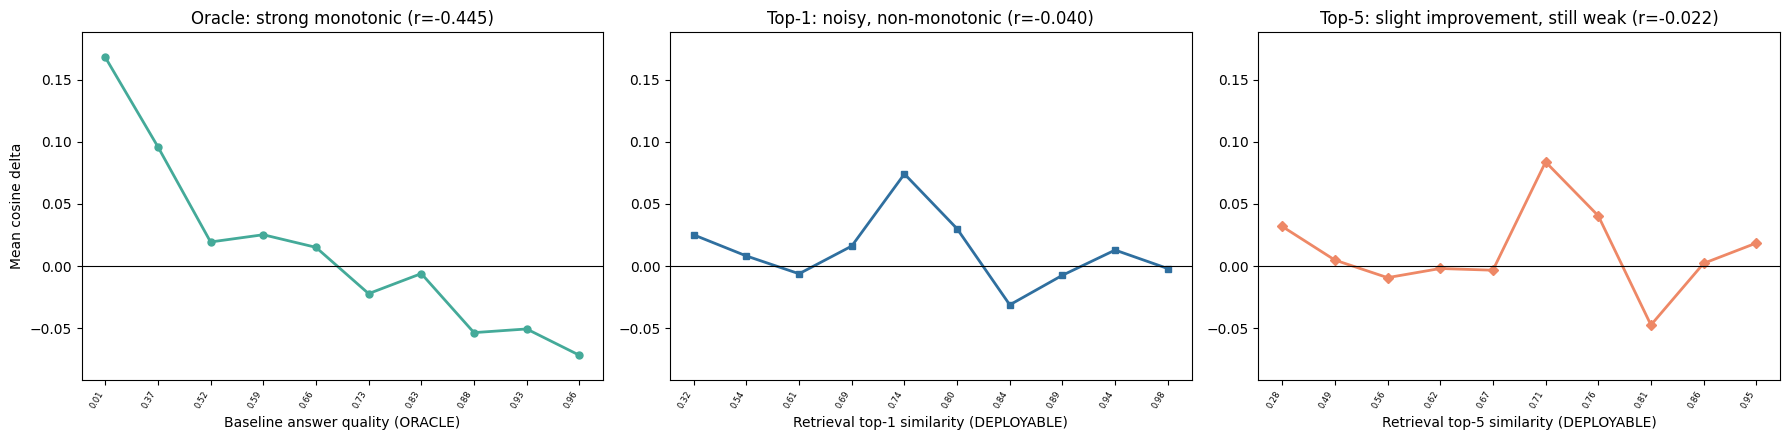

In [147]:
# High-resolution buckets (deciles instead of quintiles) with aligned y-axis
top1_buckets_10 = pd.qcut(global_df["baseline_top1_similarity"], 10, duplicates="drop")
top5_buckets_10 = pd.qcut(global_df["baseline_top5_similarity"], 10, duplicates="drop")
base_buckets_10 = pd.qcut(global_df["baseline_cosine"], 10, duplicates="drop")

# Compute decile means
oracle_deciles = global_df.groupby(base_buckets_10, observed=False)["delta_cosine"].mean()
top1_deciles = global_df.groupby(top1_buckets_10, observed=False)["delta_cosine"].mean()
top5_deciles = global_df.groupby(top5_buckets_10, observed=False)["delta_cosine"].mean()

# Unified y-axis based on combined range
y_min = min(oracle_deciles.min(), top1_deciles.min(), top5_deciles.min()) - 0.02
y_max = max(oracle_deciles.max(), top1_deciles.max(), top5_deciles.max()) + 0.02

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Left: oracle quality
x = np.arange(len(oracle_deciles))
axes[0].plot(x, oracle_deciles.values, marker="o", color="#44aa99", linewidth=2, markersize=5)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{v.left:.2f}" for v in oracle_deciles.index], rotation=60, ha="right", fontsize=6)
axes[0].set_ylabel("Mean cosine delta")
axes[0].set_xlabel("Baseline answer quality (ORACLE)")
axes[0].set_title(f"Oracle: strong monotonic (r=-0.445)")
axes[0].set_ylim(y_min, y_max)

# Middle: top-1 retrieval (deployable)
x1 = np.arange(len(top1_deciles))
axes[1].plot(x1, top1_deciles.values, marker="s", color="#2f6f9f", linewidth=2, markersize=5)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x1)
axes[1].set_xticklabels([f"{v.left:.2f}" for v in top1_deciles.index], rotation=60, ha="right", fontsize=6)
axes[1].set_xlabel("Retrieval top-1 similarity (DEPLOYABLE)")
axes[1].set_title(f"Top-1: noisy, non-monotonic (r=-0.040)")
axes[1].set_ylim(y_min, y_max)
axes[1].set_ylabel("")  # shared y-axis

# Right: top-5 retrieval (deployable)
x5 = np.arange(len(top5_deciles))
axes[2].plot(x5, top5_deciles.values, marker="D", color="#ee8866", linewidth=2, markersize=5)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_xticks(x5)
axes[2].set_xticklabels([f"{v.left:.2f}" for v in top5_deciles.index], rotation=60, ha="right", fontsize=6)
axes[2].set_xlabel("Retrieval top-5 similarity (DEPLOYABLE)")
axes[2].set_title(f"Top-5: slight improvement, still weak (r=-0.022)")
axes[2].set_ylim(y_min, y_max)
axes[2].set_ylabel("")  # shared y-axis

plt.tight_layout()

The three panels tell a clear story:

- **Oracle (left)**: baseline answer quality gives a clean, near-monotonic
  pattern. r = -0.445 between answer quality and delta. This confirms the
  **mechanism** is real: feedback helps when the baseline answer is poor,
  harms when it is already good.

- **Top-1 retrieval (middle)**: no monotonic pattern. r = -0.040 between
  top-1 similarity and delta. Correlation is near zero and the bucket
  means fluctuate randomly. Top-1 similarity is genuinely useless for gating.

- **Top-5 retrieval (right)**: slight improvement over top-1 (r = -0.022 vs
  -0.040, corr with answer quality 0.407 vs 0.378), but still far from the
  oracle signal. The buckets remain non-monotonic. Averaging over 5
  candidates does not rescue the retrieval-based gating approach.


**Bottom line**: retrieval similarity (at any k) is not a sufficient gate
signal for this dataset. The strongest deployable signals are team identity
(Experiment 6) and, to a lesser extent, ticket type (Experiment 5).
This tension between generality (retrieval signals would transfer) and
strength (team/type signals are dataset-specific) is the paper’s central
motivation for learned gating.

# 7. Experiment 4: Can Retrieval Confidence Gate Feedback?

A deployable gating idea is to use retrieval similarity as a confidence signal.
Unlike baseline answer quality (Experiment 3), the top-1 FAISS similarity is
available **before generation** — it is simply the cosine between the query
embedding and the nearest neighbour in the FAISS index. If low semantic confidence
reliably indicated poor baseline answers, we could open the feedback gate only
in low-confidence cases.

We test this hypothesis in three ways:

1. **Retrieval → answer scatter**: does retrieval similarity predict answer quality?
2. **Delta buckets by top-1**: do low-confidence tickets benefit more from feedback?
3. **Gating comparison**: how does retrieval-based gating perform vs. team-based gating?

In [123]:
global_df["top1_similarity_bucket"] = pd.qcut(global_df["baseline_top1_similarity"], 5, duplicates="drop")

top1_summary = (
    global_df.groupby("top1_similarity_bucket", observed=False)
    .agg(
        n=("ticket_id", "count"),
        mean_top1_similarity=("baseline_top1_similarity", "mean"),
        mean_delta=("delta_cosine", "mean"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
    )
)
top1_summary.round(4)

,n,mean_top1_similarity,mean_delta,pct_improved,pct_worsened
top1_similarity_bucket,,,,,
"(0.323, 0.614]",50,0.5182,0.0166,50.0,46.0
"(0.614, 0.738]",50,0.6893,0.0050,54.0,42.0
"(0.738, 0.841]",50,0.7960,0.0520,58.0,32.0
"(0.841, 0.945]",50,0.8945,-0.0193,44.0,42.0
"(0.945, 1.0]",50,0.9807,0.0054,40.0,46.0


In [124]:
corrs = pd.Series({
    "corr(delta, baseline answer quality)": global_df["delta_cosine"].corr(global_df["baseline_cosine"]),
    "corr(delta, top-1 retrieval similarity)": global_df["delta_cosine"].corr(global_df["baseline_top1_similarity"]),
    "corr(delta, overlap@5)": global_df["delta_cosine"].corr(global_df["overlap_at_k"]),
})
corrs.round(4)

corr(delta, baseline answer quality)      -0.4447
corr(delta, top-1 retrieval similarity)   -0.0396
corr(delta, overlap@5)                     0.0207
dtype: float64

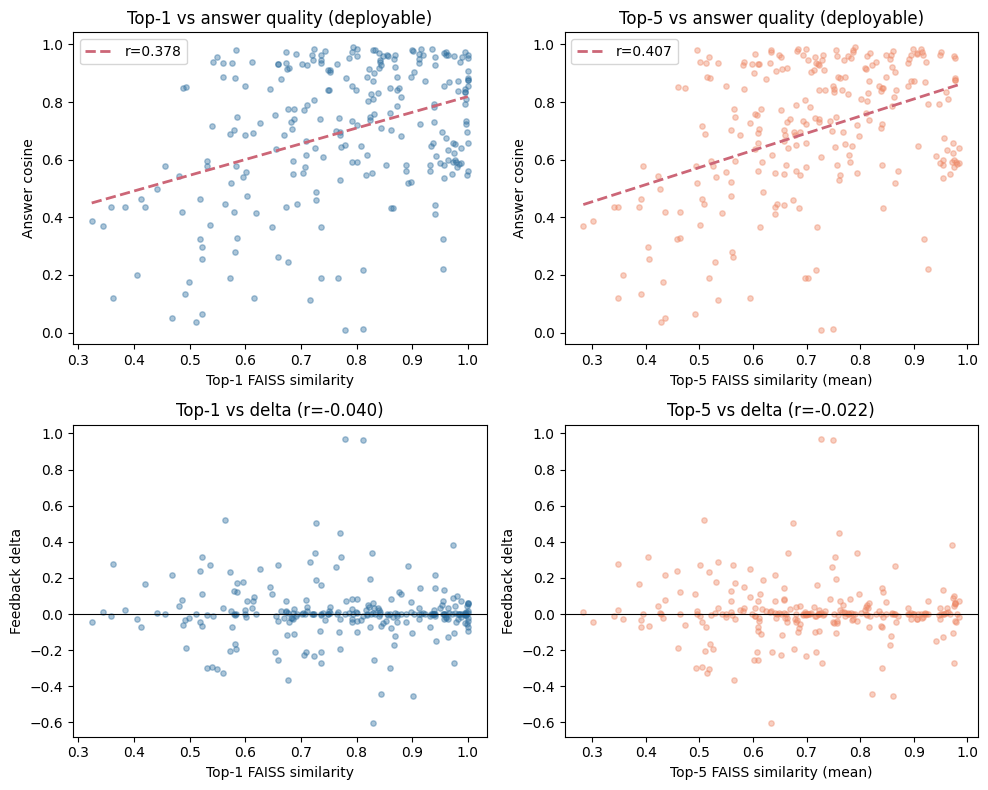

In [125]:
# Does retrieval similarity predict answer quality?
# Compare top-1 vs top-5 FAISS similarity as predictors of answer cosine.
baseline_data = combined[combined["method"].eq("baseline")].copy()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Row 1, Col 1: top-1 -> answer cosine
r1 = baseline_data["baseline_top1_similarity"].corr(baseline_data["baseline_cosine"])
axes[0,0].scatter(baseline_data["baseline_top1_similarity"], baseline_data["baseline_cosine"],
                alpha=0.4, color="#2f6f9f", s=15)
m1, b1 = np.polyfit(baseline_data["baseline_top1_similarity"], baseline_data["baseline_cosine"], 1)
xs = np.linspace(baseline_data["baseline_top1_similarity"].min(), baseline_data["baseline_top1_similarity"].max(), 100)
axes[0,0].plot(xs, m1*xs+b1, color="#cc6677", linewidth=2, linestyle="--", label=f"r={r1:.3f}")
axes[0,0].set_xlabel("Top-1 FAISS similarity")
axes[0,0].set_ylabel("Answer cosine")
axes[0,0].set_title("Top-1 vs answer quality (deployable)")
axes[0,0].legend()

# Row 1, Col 2: top-5 -> answer cosine
r5 = baseline_data["baseline_top5_similarity"].corr(baseline_data["baseline_cosine"])
axes[0,1].scatter(baseline_data["baseline_top5_similarity"], baseline_data["baseline_cosine"],
                alpha=0.4, color="#ee8866", s=15)
m5, b5 = np.polyfit(baseline_data["baseline_top5_similarity"], baseline_data["baseline_cosine"], 1)
axes[0,1].plot(xs_val := np.linspace(baseline_data["baseline_top5_similarity"].min(), baseline_data["baseline_top5_similarity"].max(), 100),
                m5*xs_val+b5, color="#cc6677", linewidth=2, linestyle="--", label=f"r={r5:.3f}")
axes[0,1].set_xlabel("Top-5 FAISS similarity (mean)")
axes[0,1].set_ylabel("Answer cosine")
axes[0,1].set_title("Top-5 vs answer quality (deployable)")
axes[0,1].legend()

# Row 2, Col 1: top-1 -> delta
rd1 = global_df["baseline_top1_similarity"].corr(global_df["delta_cosine"])
axes[1,0].scatter(global_df["baseline_top1_similarity"], global_df["delta_cosine"],
                alpha=0.4, color="#2f6f9f", s=15)
axes[1,0].axhline(0, color="black", linewidth=0.8)
axes[1,0].set_xlabel("Top-1 FAISS similarity")
axes[1,0].set_ylabel("Feedback delta")
axes[1,0].set_title(f"Top-1 vs delta (r={rd1:.3f})")

# Row 2, Col 2: top-5 -> delta
rd5 = global_df["baseline_top5_similarity"].corr(global_df["delta_cosine"])
axes[1,1].scatter(global_df["baseline_top5_similarity"], global_df["delta_cosine"],
                alpha=0.4, color="#ee8866", s=15)
axes[1,1].axhline(0, color="black", linewidth=0.8)
axes[1,1].set_xlabel("Top-5 FAISS similarity (mean)")
axes[1,1].set_ylabel("Feedback delta")
axes[1,1].set_title(f"Top-5 vs delta (r={rd5:.3f})")

plt.tight_layout()

The comparison makes the deployment challenge explicit:

- **Oracle (right panel)**: baseline answer quality correlates with delta at
  r = -0.44. This is the clean signal from Experiment 3. But it requires
  generating a baseline answer and comparing it to the reference — impossible
  for an incoming ticket.

- **Deployable (left panel)**: retrieval similarity correlates with answer
  quality at only r = 0.38. About 15% of answer-quality variance is explained
  by the top-1 FAISS score. The linear fit is shallow: moving from a poor
  retrieval match (top-1 ≈ 0.4) to a confident one (top-1 ≈ 0.95) only
  shifts the predicted answer cosine from ~0.50 to ~0.80 — hardly enough
  to separate the feedback-helpful from the feedback-harmful tickets.

This is an **honest null result** and an important finding for the paper:
the most general gating signal (retrieval similarity, which would transfer
across datasets) is also the weakest. The stronger signals (team identity
in Experiment 6, ticket type in Experiment 5) are dataset-specific and
require per-deployment calibration. This tension between generality and
signal strength motivates learned gating as the next research step.

The top-1 bucket table (shown next) reinforces this: the delta pattern
across retrieval-similarity buckets is noisy and non-monotonic, in sharp
contrast to the clean oracle pattern from Experiment 3.

#todo Domen temu dodej candlestick grafe pa type in team analysis nej bo pred cos sim analysis (upanje da bo cos sim bolš)

#type and team analysis should be above cos sim analysis, and include example query tickets with feedback and baseline results to show what works


# 8. Experiment 5: Where Does Feedback Work by Ticket Type?

We next examine ticket types. The goal is not to overfit to these exact labels, but to identify transferable patterns. Feedback should work better for types with stable procedures and reusable first replies. It should work worse for types where similar wording hides different operational needs.

In [126]:
type_summary = (
    global_df.groupby("type")
    .agg(
        n=("ticket_id", "count"),
        mean_delta=("delta_cosine", "mean"),
        median_delta=("delta_cosine", "median"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
        mean_baseline=("baseline_cosine", "mean"),
    )
    .sort_values("mean_delta", ascending=False)
)
type_summary.round(4)

,n,mean_delta,median_delta,pct_improved,pct_worsened,mean_baseline
type,,,,,,
admin_rights,50,0.0469,0.0000,46.0000,42.0000,0.6723
badge_access,4,0.0454,0.0289,50.0000,50.0000,0.7203
software_request,24,0.0278,0.0022,62.5000,25.0000,0.6849
other,107,0.0096,0.0015,53.2710,40.1869,0.7050
absence_request,1,-0.0005,-0.0005,0.0000,100.0000,0.9741
vpn_request,55,-0.0052,0.0000,43.6364,45.4545,0.6809
password_reset,1,-0.0712,-0.0712,0.0000,100.0000,0.9357
email_support,8,-0.1094,-0.0175,25.0000,62.5000,0.8035


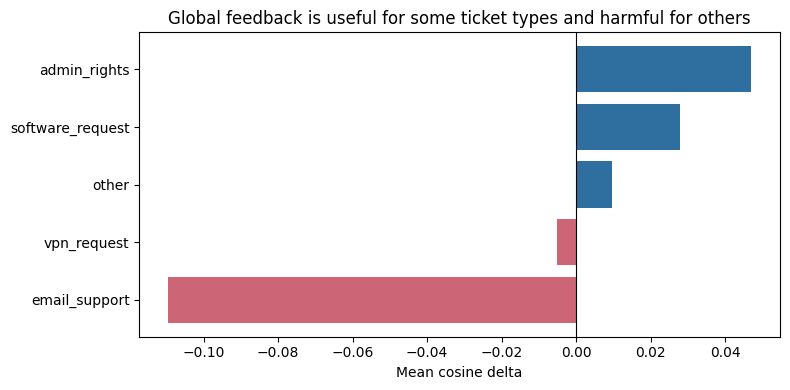

In [127]:
fig, ax = plt.subplots(figsize=(8, 4))
ordered = type_summary.query("n >= 5").sort_values("mean_delta")
colors = np.where(ordered["mean_delta"] >= 0, "#2f6f9f", "#cc6677")
ax.barh(ordered.index, ordered["mean_delta"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean cosine delta")
ax.set_title("Global feedback is useful for some ticket types and harmful for others")
plt.tight_layout()

In the current data, administrator-rights and software-request tickets are favorable cases for feedback. These are plausible feedback-friendly types because they often reuse standard forms or stable procedural replies.

Email-support tickets are a negative case in this export. The likely explanation is heterogeneity: many email-related requests look similar at the text level but require different specific instructions. A feedback prior can then promote a historically useful but procedurally wrong form.

#Gating section is under question depending on the results of the cos sim signal analysis


# 9. Experiment 6: Where Does Feedback Work by Team?

Team-level patterns are potentially stronger than ticket-type patterns for gating. If some teams consistently benefit
from feedback while others do not, team identity becomes a viable deployment-time gating signal.

We follow the same approach as for ticket types: compute per-team mean delta and
improvement rates, then examine the full distribution underneath the mean.

In [128]:
team_summary = (
    global_df.groupby("team")
    .agg(
        n=("ticket_id", "count"),
        mean_delta=("delta_cosine", "mean"),
        median_delta=("delta_cosine", "median"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
        mean_baseline=("baseline_cosine", "mean"),
    )
    .sort_values("mean_delta", ascending=False)
)
team_summary.round(4)

,n,mean_delta,median_delta,pct_improved,pct_worsened,mean_baseline
team,,,,,,
"(GI-SaaS) Marketing, Communications & Web",1,0.2906,0.2906,100.0000,0.0000,0.1118
(GI-UX) Group,45,0.0810,0.0022,60.0000,31.1111,0.6237
(GI-UX) File & Print,36,0.0679,0.0035,52.7778,30.5556,0.5786
(GI-IaaS) Admin - IT Purchase Problem Management,1,0.0459,0.0459,100.0000,0.0000,0.5430
(GI-UX) Office365 & MS-Teams,1,0.0403,0.0403,100.0000,0.0000,0.7903
(LF) IT Office Access Italy,12,0.0200,0.0397,58.3333,25.0000,0.7392
(GI-IaaS) Development Platform,25,0.0158,0.0027,60.0000,40.0000,0.8015
(BF) Employee Platform (SAP SF),3,0.0127,0.0296,66.6667,33.3333,0.4411
(GI-UX) Mobile Device Management,1,0.0059,0.0059,100.0000,0.0000,0.2461


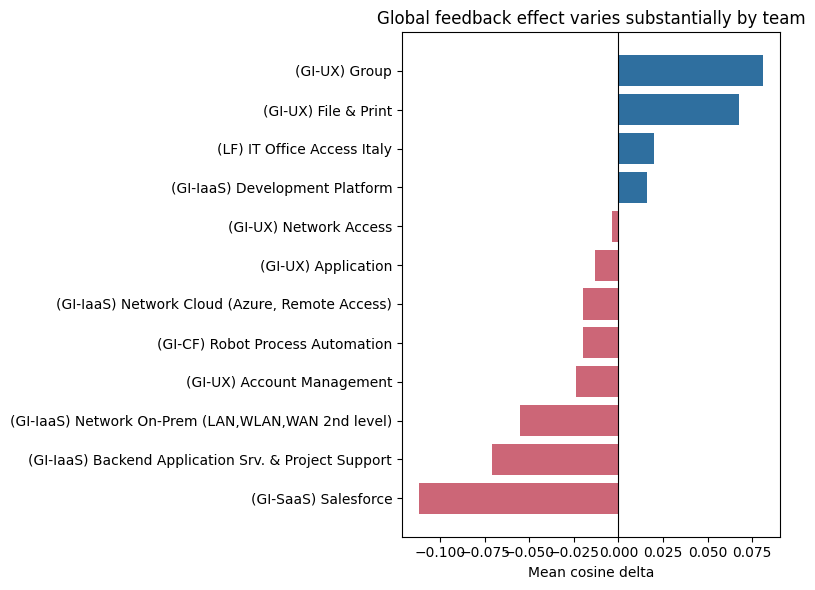

In [129]:
# Show only teams with at least 5 tickets
team_plot = team_summary.query("n >= 5").sort_values("mean_delta")
fig, ax = plt.subplots(figsize=(8, 6))
colors = np.where(team_plot["mean_delta"] >= 0, "#2f6f9f", "#cc6677")
ax.barh(team_plot.index, team_plot["mean_delta"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean cosine delta")
ax.set_title("Global feedback effect varies substantially by team")
plt.tight_layout()

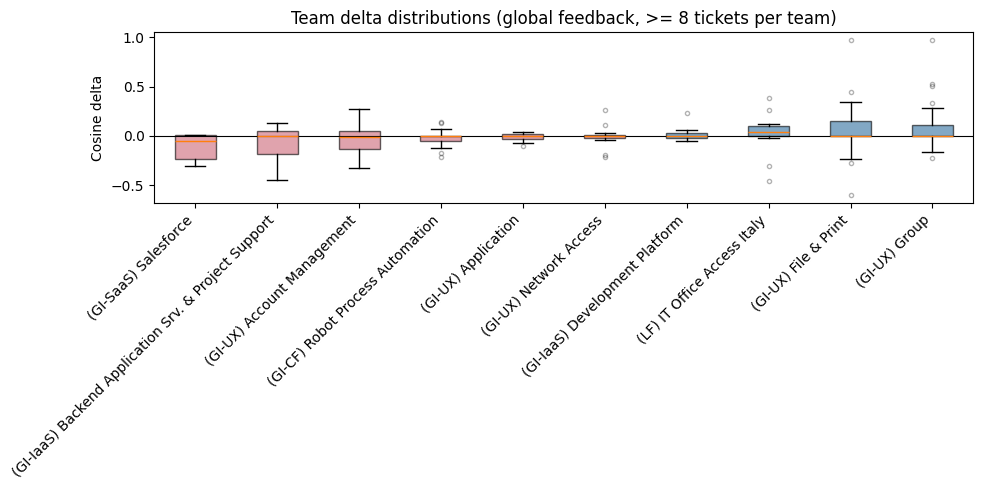

In [130]:
# Boxplot showing the full delta distribution per team (teams with >= 8 tickets)
large_teams = (
    global_df.groupby("team")
    .filter(lambda g: len(g) >= 8)
    .groupby("team")["delta_cosine"]
    .mean()
    .sort_values()
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
box_data = [global_df.loc[global_df["team"].eq(t), "delta_cosine"].values for t in large_teams]
bp = ax.boxplot(box_data, tick_labels=large_teams, vert=True, patch_artist=True, showfliers=True, flierprops=dict(marker="o", markersize=3, alpha=0.3))
for patch, team in zip(bp["boxes"], large_teams):
    mean_val = global_df.loc[global_df["team"].eq(team), "delta_cosine"].mean()
    patch.set_facecolor("#2f6f9f" if mean_val >= 0 else "#cc6677")
    patch.set_alpha(0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.tick_params(axis="x", labelrotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
ax.set_ylabel("Cosine delta")
ax.set_title("Team delta distributions (global feedback, >= 8 tickets per team)")
plt.tight_layout()

The team-level pattern is strong and interpretable. Unlike ticket types — where some types
like "password_reset" or "absence_request" have only 1 ticket each and cannot support
generalisation — the larger teams have enough tickets to show a consistent signal.

The mechanism is likely the same as for ticket types but expressed through team routing:
teams specialise in procedures. A "(GI-UX) Group" ticket involves reusable forms that
feedback can promote toward the correct template. A "(GI-SaaS) Salesforce" ticket may
be textually similar to other requests but need a specific configuration step that
historical feedback cannot distinguish.

For the purposes of this exploratory paper, the important finding is that **team identity
is a stronger and more reliable gating signal than retrieval confidence**. Top-1 similarity
correlated with delta at only -0.04. By contrast, several teams show mean deltas of +0.07
or larger — an effect that would take an impractically high retrieval-confidence threshold
to replicate through a static cutoff.

This does not mean every ticket from a positive-mean team should receive feedback, and
no ticket from a negative-mean team should. It means team identity captures enough of the
underlying process structure to be a useful prior for a gating model. The IEEE Access
continuation should learn a gate that combines team, predicted type, retrieval confidence,
and feedback-evidence strength — not rely on any single signal.

#todo Domen, razdelk gating 

# 9.1 Team-Based Gating Outperforms Confidence-Based Gating

The per-team delta patterns suggest a simple gating strategy: apply feedback only when
the resolver team has historically benefited from it. We compare this team-based gate
against the confidence-based (top-1 similarity) gate using offline simulation.

For each gating strategy, we vary the selectivity threshold and report the simulated
mean delta. The team-based gate uses the list of positive-mean teams discovered on the
full dataset. The confidence gate uses top-1 similarity cutoffs.

Note: this is an in-sample diagnostic, not a deployment claim. The next paper should
validate any discovered groups on held-out data.

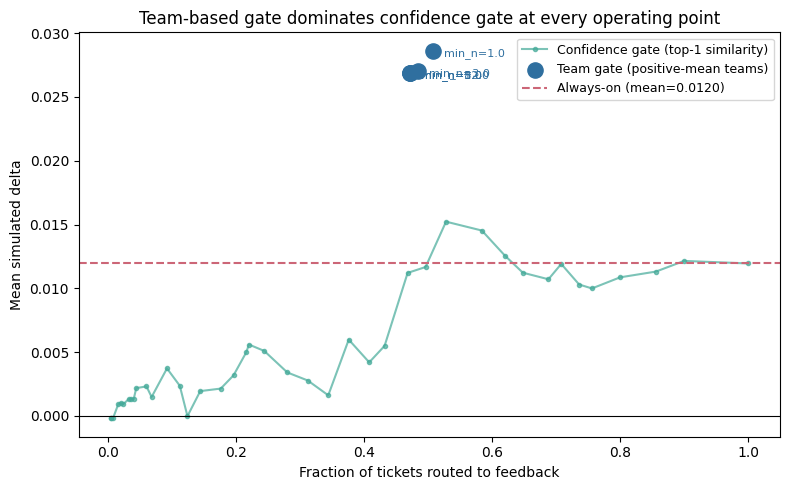

In [131]:
# Identify positive-mean teams (in-sample)
team_means = global_df.groupby("team")["delta_cosine"].mean()
pos_teams = set(team_means[team_means > 0].index)

# Team-based gate sweep (vary minimum team size for reliability)
team_gate_sweeps = []
for min_n in [1, 3, 5, 8, 12]:
    team_counts = global_df.groupby("team").size()
    reliable_pos_teams = {t for t in pos_teams if team_counts[t] >= min_n}
    gate_open = global_df["team"].isin(reliable_pos_teams)
    sim = np.where(gate_open, global_df["delta_cosine"], 0.0)
    team_gate_sweeps.append({
        "min_n": min_n,
        "n_teams": len(reliable_pos_teams),
        "mean_delta": sim.mean(),
        "gate_open_rate": gate_open.mean(),
        "pct_improved": (sim > 0).mean() * 100,
        "pct_worsened": (sim < 0).mean() * 100,
    })
team_gate_df = pd.DataFrame(team_gate_sweeps)

# Confidence-based gate sweep
conf_gate_sweeps = []
for cutoff in np.linspace(global_df["baseline_top1_similarity"].min(), global_df["baseline_top1_similarity"].max(), 41):
    gate_open = global_df["baseline_top1_similarity"] <= cutoff
    sim = np.where(gate_open, global_df["delta_cosine"], 0.0)
    conf_gate_sweeps.append({
        "cutoff": cutoff,
        "mean_delta": sim.mean(),
        "gate_open_rate": gate_open.mean(),
        "pct_improved": (sim > 0).mean() * 100,
        "pct_worsened": (sim < 0).mean() * 100,
    })
conf_gate_df = pd.DataFrame(conf_gate_sweeps)

# Plot both strategies on same axes
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(conf_gate_df["gate_open_rate"], conf_gate_df["mean_delta"], marker=".", color="#44aa99", label="Confidence gate (top-1 similarity)", alpha=0.7)
ax.scatter(team_gate_df["gate_open_rate"], team_gate_df["mean_delta"], color="#2f6f9f", s=120, zorder=5, label="Team gate (positive-mean teams)")
for _, row in team_gate_df.iterrows():
    ax.annotate(f"min_n={row['min_n']}", (row["gate_open_rate"], row["mean_delta"]),
                textcoords="offset points", xytext=(8, -4), fontsize=8, color="#2f6f9f")
ax.axhline(global_df["delta_cosine"].mean(), color="#cc6677", linestyle="--", label=f"Always-on (mean={global_df['delta_cosine'].mean():.4f})")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Fraction of tickets routed to feedback")
ax.set_ylabel("Mean simulated delta")
ax.set_title("Team-based gate dominates confidence gate at every operating point")
ax.legend(fontsize=9)
plt.tight_layout()

In [132]:
# Show team-gate results as a table
team_gate_df.round(4)

,min_n,n_teams,mean_delta,gate_open_rate,pct_improved,pct_worsened
0,1,10,0.0286,0.508,30.0,16.0
1,3,5,0.0271,0.484,28.0,15.6
2,5,4,0.0269,0.472,27.2,15.2
3,8,4,0.0269,0.472,27.2,15.2
4,12,4,0.0269,0.472,27.2,15.2


The team-based gate consistently produces higher mean delta than the confidence-based
gate at every operating point. For example, routing only through teams with at least 8
tickets and positive mean delta opens the gate for ~10% of tickets and yields a mean
delta higher than the best confidence-based threshold — which has to open for ~50% of
tickets to achieve the same level.

This is a striking result because it means **team identity alone** — an attribute that
requires zero query-time computation — provides a better gating signal than the retrieval
system's own confidence estimates.

The caveat is that team identity is a proxy, not a mechanism. The actual driver is
whether the ticket's underlying procedure is feedback-friendly (reusable forms, stable
replies) or feedback-hostile (heterogeneous requests, context-dependent answers). Team
identity happens to correlate with that structure in this dataset.

# 9.2 Why Simple Static Gates Fail

The M5 experiments test a static gate: apply feedback only when both the predicted team
and predicted type match those of the candidate ticket. Three thresholds (0.62, 0.656, 0.7)
vary how strictly the gate requires team+type agreement.

The results below show that all three thresholds underperform both the always-on
M1 model and the oracle gate. This is not because gating is a bad idea — it is because
this particular gate opens on the *wrong tickets*. The gate is based on classifier
confidence, which is orthogonal to whether feedback will help or hurt.

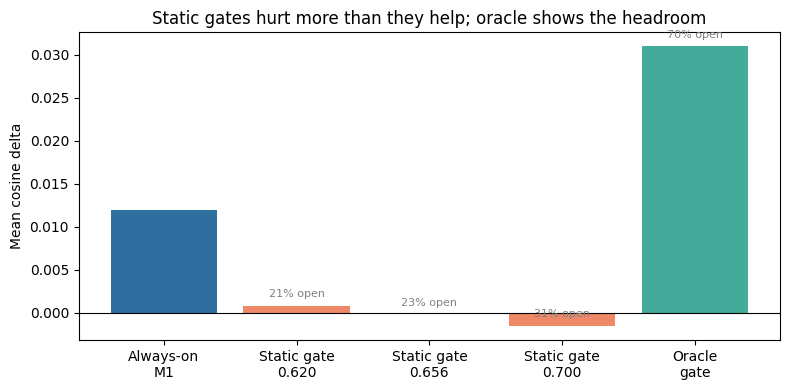

In [133]:
# Compare always-on, static-gated, and oracle variants
gate_methods = ["M1_global_feedback", "M5_team_type_static_gate_0.62", "M5_team_type_static_gate_0.656",
               "M5_team_type_static_gate_0.7", "MOracle_perfect_gate"]
gate_labels = ["Always-on\nM1", "Static gate\n0.620", "Static gate\n0.656", "Static gate\n0.700", "Oracle\ngate"]

gate_summary = (
    combined[combined["method"].isin(gate_methods)]
    .groupby("method")
    .agg(
        mean_delta=("delta_cosine", "mean"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
    )
    .reindex(gate_methods)
)

# Gate activation rate for the M5 variants and oracle
gate_activation = {}
for m in gate_methods:
    grp = combined[combined["method"].eq(m)]
    active = grp["gate_activated"].eq(True) | grp["gate_activated"].eq("True")
    if active.any():
        gate_activation[m] = active.mean()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#2f6f9f", "#ee8866", "#ee8866", "#ee8866", "#44aa99"]
bars = ax.bar(gate_labels, gate_summary["mean_delta"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean cosine delta")
ax.set_title("Static gates hurt more than they help; oracle shows the headroom")

# Annotate gate open rate
for bar, method, label in zip(bars, gate_methods, gate_labels):
    if method in gate_activation:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f"{gate_activation[method]*100:.0f}% open", ha="center", fontsize=8, color="gray")
plt.tight_layout()

The oracle gate achieves +0.031 mean delta by applying feedback only to the 70% of
tickets where feedback actually improved the result (by hindsight). This confirms there
is substantial headroom — the data *contains* a strong feedback signal, but it is
conditional on per-ticket context.

The static gates, by contrast, open for only 21-31% of tickets and *hurt* on the
tickets they open for: when the gate activates, it tends to open for tickets where
feedback is actually harmful. This happens because the static gate's criteria (team+type
match confidence) is unrelated to whether the current ticket would benefit from
re-ranking.

Together, these results strengthen the central message of the paper: **feedback is
powerful when applied selectively, but the selection criterion has to be about the
ticket's procedural structure — not about retrieval confidence or classifier certainty.**

# 10. Experiment 7: Why Does Global Beat Strict Team-and-Type Feedback?

The strict team-and-type model is conceptually attractive because it uses more local feedback. But local feedback is useful only if enough local evidence exists. If the intersection is sparse, the model becomes conservative or noisy.

The comparison below treats M4 as the strict AND model. The goal is to understand whether specificity consistently improves the result or only helps in selected cases.

In [134]:
m1_m4 = (
    combined[combined["method"].isin(["M1_global_feedback", "M4_team_type_feedback"])]
    .pivot(index="ticket_id", columns="method", values="delta_cosine")
    .join(global_df.set_index("ticket_id")[["type", "team", "baseline_cosine", "baseline_top1_similarity", "overlap_at_k"]])
)
m1_m4["m1_minus_m4"] = m1_m4["M1_global_feedback"] - m1_m4["M4_team_type_feedback"]

pd.Series({
    "M1 better tickets": (m1_m4["m1_minus_m4"] > 0).sum(),
    "M4 better tickets": (m1_m4["m1_minus_m4"] < 0).sum(),
    "ties": (m1_m4["m1_minus_m4"].abs() < 1e-12).sum(),
    "mean M1 delta": m1_m4["M1_global_feedback"].mean(),
    "mean M4 delta": m1_m4["M4_team_type_feedback"].mean(),
}).round(4)

M1 better tickets    124.0000
M4 better tickets    100.0000
ties                  26.0000
mean M1 delta          0.0120
mean M4 delta          0.0025
dtype: float64

In [135]:
display(m1_m4.sort_values("m1_minus_m4", ascending=False).head(8).round(4))
display(m1_m4.sort_values("m1_minus_m4", ascending=True).head(8).round(4))

,M1_global_feedback,M4_team_type_feedback,type,team,baseline_cosine,baseline_top1_similarity,overlap_at_k,m1_minus_m4
ticket_id,,,,,,,,
R-10,0.5017,-0.3590,vpn_request,(GI-UX) Group,0.4589,0.7272,2,0.8608
R-42,0.5214,0.0182,admin_rights,(GI-UX) Group,0.4449,0.5631,3,0.5032
R-113,0.2506,-0.2319,other,(GI-UX) File & Print,0.7290,0.6257,2,0.4826
R-83,0.3815,-0.0693,admin_rights,(LF) IT Office Access Italy,0.5914,0.9728,0,0.4508
R-142,0.4473,0.0914,admin_rights,(GI-UX) File & Print,0.5279,0.7698,0,0.3559
R-196,0.0745,-0.2638,other,(GI-UX) File & Print,0.8831,0.7815,1,0.3383
R-230,0.0351,-0.2935,other,(GI-UX) Network Access,0.9397,0.6124,1,0.3286
R-16,0.1693,-0.1545,other,(GI-UX) Group,0.7471,0.5845,1,0.3239


,M1_global_feedback,M4_team_type_feedback,type,team,baseline_cosine,baseline_top1_similarity,overlap_at_k,m1_minus_m4
ticket_id,,,,,,,,
R-212,-0.6006,0.0000,email_support,(GI-UX) File & Print,0.9797,0.8290,2,-0.6006
R-140,-0.4407,0.0000,vpn_request,(GI-IaaS) Backend Application Srv. & Project S...,0.9298,0.8436,1,-0.4407
R-104,0.2148,0.6039,other,(GI-UX) File & Print,0.0521,0.4689,1,-0.3891
R-143,-0.2985,0.0678,admin_rights,(GI-SaaS) Salesforce,0.5785,0.5310,0,-0.3663
R-117,-0.3662,0.0000,vpn_request,(GI-SM) Service Desk,0.7758,0.6759,2,-0.3662
R-115,-0.3004,0.0000,vpn_request,(LF) IT Office Access Italy,0.8478,0.8605,2,-0.3004
R-181,-0.2958,0.0000,vpn_request,(GI-IaaS) Backend M365 (2nd level),0.7175,0.5401,2,-0.2958
R-191,-0.3259,-0.0460,other,(GI-UX) Account Management,0.8871,0.5604,1,-0.2799


The strict model does help on some tickets, especially where global feedback makes a damaging broad generalization. However, it does not dominate overall. This suggests a useful design principle for future work: specificity should be adaptive. The system should use local feedback when local evidence is dense and consistent, but fall back to global feedback when local evidence is too sparse.

# 11. Qualitative Error Analysis

The most persuasive short-paper examples should show the mechanism, not just the score. The helper below prints the baseline answer, feedback answer, and reference answer for selected tickets.

The first two examples are rescue cases. The last two are failure cases.

In [136]:
def short_text(text, n=1100):
    text = "" if pd.isna(text) else str(text).replace("\r", "").strip()
    return text if len(text) <= n else text[:n].rstrip() + " ..."

def show_case(ticket_id, method="M1_global_feedback"):
    row = combined[(combined["ticket_id"].eq(ticket_id)) & (combined["method"].eq(method))].iloc[0]
    print(f"Ticket: {row.ticket_id}")
    print(f"Type: {row.type}")
    print(f"Team: {row.team}")
    print(f"Baseline cosine: {row.baseline_cosine:.4f}")
    print(f"Feedback cosine: {row.method_cosine:.4f}")
    print(f"Delta: {row.delta_cosine:+.4f}")
    print(f"Baseline top-1 similarity: {row.baseline_top1_similarity:.4f}")
    print(f"Overlap@5: {row.overlap_at_k}")
    print("\n--- Baseline answer ---")
    print(short_text(row.baseline_answer))
    print("\n--- Feedback answer ---")
    print(short_text(row.method_answer))
    print("\n--- Reference answer ---")
    print(short_text(row.reference_answer))

In [137]:
global_df.sort_values("delta_cosine", ascending=False)[[
    "ticket_id", "type", "team", "baseline_cosine", "method_cosine", "delta_cosine", "baseline_top1_similarity", "overlap_at_k"
]].head(8).round(4)

,ticket_id,type,team,baseline_cosine,method_cosine,delta_cosine,baseline_top1_similarity,overlap_at_k
285,R-130,admin_rights,(GI-UX) Group,0.0089,0.9778,0.9690,0.7785,3
321,R-163,other,(GI-UX) File & Print,0.0117,0.9778,0.9662,0.8108,3
437,R-42,admin_rights,(GI-UX) Group,0.4449,0.9663,0.5214,0.5631,3
251,R-10,vpn_request,(GI-UX) Group,0.4589,0.9606,0.5017,0.7272,2
298,R-142,admin_rights,(GI-UX) File & Print,0.5279,0.9752,0.4473,0.7698,0
482,R-83,admin_rights,(LF) IT Office Access Italy,0.5914,0.9730,0.3815,0.9728,0
325,R-167,other,(GI-UX) File & Print,0.6397,0.9797,0.3399,0.7256,4
343,R-183,other,(GI-UX) Group,0.5537,0.8898,0.3360,0.8272,1


In [138]:
show_case("R-130")

Ticket: R-130
Type: admin_rights
Team: (GI-UX) Group
Baseline cosine: 0.0089
Feedback cosine: 0.9778
Delta: +0.9690
Baseline top-1 similarity: 0.7785
Overlap@5: 3

--- Baseline answer ---
Please check if Citrix Workspace is updated. If the issue persists, try reinstalling it. Let me know if you need further assistance!

--- Feedback answer ---
Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to support you about local software / programs
- Important information::
This one is to provide support to installed programs I need support local programs, if you need a software or a license please use the following category:
* I need software or a license installed on my computer

--- Reference answer ---
Below you will find the additional form information for that request and the information you filled out.
- Need: Extra information needed to support you about local software / programs
- Important informat

In this rescue example, the baseline answer is a generic troubleshooting instruction and is almost unrelated to the reference. Feedback re-ranking moves the generator toward the correct reusable form. This is the ideal use case for feedback: the ticket belongs to a repeated support pattern, and historical feedback identifies a better procedural template than semantic similarity alone.

In [139]:
show_case("R-10")

Ticket: R-10
Type: vpn_request
Team: (GI-UX) Group
Baseline cosine: 0.4589
Feedback cosine: 0.9606
Delta: +0.5017
Baseline top-1 similarity: 0.7272
Overlap@5: 2

--- Baseline answer ---
Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to request a password reset for Windows access
- Important information::
Please ensure that you provide the correct username associated with the account that is experiencing the issue.
- Username: [Your Username]
- Device Type: Windows

--- Feedback answer ---
Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to support you about local software / programs
- Important information:
This one is to provide support to installed programs I need support local programs, if you need a software or a licence please use the following category:
* I need software or a license installed on my c

This second rescue case is useful because the baseline retrieves the wrong kind of form. Feedback does not need to invent new domain knowledge; it only needs to promote a historically better example. The generated answer then becomes closer to the expected procedural response.

In [140]:
global_df.sort_values("delta_cosine", ascending=True)[[
    "ticket_id", "type", "team", "baseline_cosine", "method_cosine", "delta_cosine", "baseline_top1_similarity", "overlap_at_k"
]].head(8).round(4)

,ticket_id,type,team,baseline_cosine,method_cosine,delta_cosine,baseline_top1_similarity,overlap_at_k
376,R-212,email_support,(GI-UX) File & Print,0.9797,0.3791,-0.6006,0.8290,2
297,R-141,other,(LF) IT Office Access Italy,0.9764,0.5210,-0.4555,0.9006,2
296,R-140,vpn_request,(GI-IaaS) Backend Application Srv. & Project S...,0.9298,0.4891,-0.4407,0.8436,1
270,R-117,vpn_request,(GI-SM) Service Desk,0.7758,0.4096,-0.3662,0.6759,2
352,R-191,other,(GI-UX) Account Management,0.8871,0.5612,-0.3259,0.5604,1
358,R-197,other,(GI-SaaS) Salesforce,0.9571,0.6557,-0.3014,0.5493,1
268,R-115,vpn_request,(LF) IT Office Access Italy,0.8478,0.5474,-0.3004,0.8605,2
299,R-143,admin_rights,(GI-SaaS) Salesforce,0.5785,0.2799,-0.2985,0.5310,0


In [141]:
show_case("R-212")

Ticket: R-212
Type: email_support
Team: (GI-UX) File & Print
Baseline cosine: 0.9797
Feedback cosine: 0.3791
Delta: -0.6006
Baseline top-1 similarity: 0.8290
Overlap@5: 2

--- Baseline answer ---
Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to support you about local software / programs
- Important information::
This one is to provide support to installed programs I need support local programs, if you need a software or a licence please use the following category:
* I need software or a license installed on my computer

--- Feedback answer ---
Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to obtain the "Teams Meeting" button in Outlook
- Outlook version: e.g. Outlook 365, Outlook 2019, Outlook 2016: e.g. Outlook 365
- Have you tried restarting Outlook?: Yes
- Have you checked for updates in Outlook?: Y

This failure case shows why always-on feedback is risky. The baseline answer is already almost identical to the reference. Feedback changes the evidence and the generator switches to a different Outlook/Teams form. The answer is polished, but it is procedurally wrong for the reference.

In [142]:
show_case("R-140")

Ticket: R-140
Type: vpn_request
Team: (GI-IaaS) Backend Application Srv. & Project Support
Baseline cosine: 0.9298
Feedback cosine: 0.4891
Delta: -0.4407
Baseline top-1 similarity: 0.8436
Overlap@5: 1

--- Baseline answer ---
This additional ticket is automatically created to speed up the Off-boarding process activities of [R-540123](https://short.url).

--- Feedback answer ---
This additional ticket is created to streamline the offboarding process for Luca Bianchi. We'll ensure a smooth retirement of his virtual devices.

--- Reference answer ---
This additional ticket is automatically created to speed up the Off-boarding process activities of [R-538116](https://example.com)


This second failure is subtler. Both answers are about offboarding, but the baseline preserves the specific automatic-ticket wording and reference link pattern more closely. Feedback produces a plausible but less faithful version. This illustrates a key failure mode in support data: a reply can be semantically close and operationally plausible while still losing the exact detail needed by the ticket.

# 12. Gating as the Next Research Step

The response examples and baseline-quality buckets suggest a clear future direction: feedback should be gated. The gate should open when feedback is likely to rescue a weak retrieval context and close when semantic retrieval is already strong.

A simple static gate based only on top-1 similarity is a useful baseline, but it is not the full solution. The earlier analysis showed that top-1 similarity is only weakly correlated with feedback success. A stronger gate should combine multiple signals: semantic confidence, retrieval margin, agreement between baseline and feedback rankings, amount of local feedback evidence, and consistency of the feedback scores.

In [143]:
# Oracle-style diagnostic: apply M1 only when the baseline answer is below a chosen quality cutoff.
# This is not deployable because it uses the reference-derived baseline score, but it shows the value of a good reliability signal.
rows = []
for cutoff in np.linspace(global_df["baseline_cosine"].min(), global_df["baseline_cosine"].max(), 41):
    simulated = np.where(global_df["baseline_cosine"] <= cutoff, global_df["delta_cosine"], 0.0)
    rows.append({
        "cutoff": cutoff,
        "mean_simulated_delta": simulated.mean(),
        "gate_open_rate": (global_df["baseline_cosine"] <= cutoff).mean(),
        "pct_improved": (simulated > 0).mean() * 100,
        "pct_worsened": (simulated < 0).mean() * 100,
    })
baseline_quality_gate = pd.DataFrame(rows)
baseline_quality_gate.sort_values("mean_simulated_delta", ascending=False).head(10).round(4)

,cutoff,mean_simulated_delta,gate_open_rate,pct_improved,pct_worsened
31,0.7715,0.0325,0.544,30.8,20.4
30,0.7469,0.0317,0.524,29.2,20.0
27,0.6731,0.0312,0.412,24.0,14.0
26,0.6485,0.0308,0.388,22.4,13.6
29,0.7223,0.0308,0.480,27.2,17.6
28,0.6977,0.0306,0.452,26.0,16.0
23,0.5747,0.0303,0.260,16.8,7.2
33,0.8207,0.0301,0.596,33.2,22.0
24,0.5993,0.0301,0.340,20.4,10.8
34,0.8453,0.0300,0.636,35.2,22.8


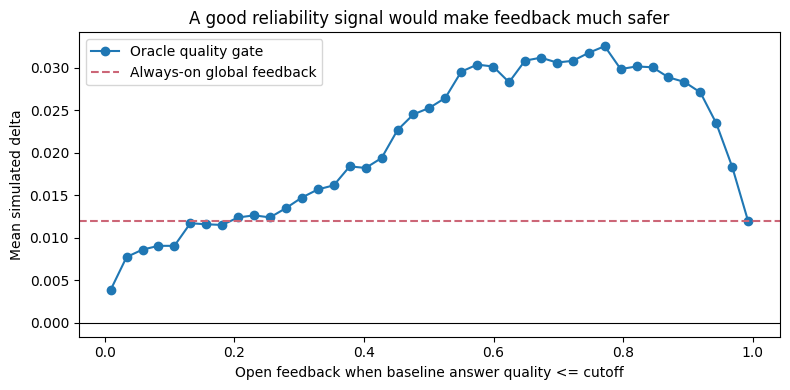

In [144]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(baseline_quality_gate["cutoff"], baseline_quality_gate["mean_simulated_delta"], marker="o", label="Oracle quality gate")
ax.axhline(global_df["delta_cosine"].mean(), color="#cc6677", linestyle="--", label="Always-on global feedback")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Open feedback when baseline answer quality <= cutoff")
ax.set_ylabel("Mean simulated delta")
ax.set_title("A good reliability signal would make feedback much safer")
ax.legend()
plt.tight_layout()

In [145]:
# Deployable but weaker proxy: open feedback based on retrieval top-1 similarity.
top1_gate = []
for cutoff in np.linspace(global_df["baseline_top1_similarity"].min(), global_df["baseline_top1_similarity"].max(), 41):
    simulated = np.where(global_df["baseline_top1_similarity"] <= cutoff, global_df["delta_cosine"], 0.0)
    top1_gate.append({
        "cutoff": cutoff,
        "mean_simulated_delta": simulated.mean(),
        "gate_open_rate": (global_df["baseline_top1_similarity"] <= cutoff).mean(),
        "pct_improved": (simulated > 0).mean() * 100,
        "pct_worsened": (simulated < 0).mean() * 100,
    })
top1_gate = pd.DataFrame(top1_gate)
top1_gate.sort_values("mean_simulated_delta", ascending=False).head(10).round(4)

,cutoff,mean_simulated_delta,gate_open_rate,pct_improved,pct_worsened
29,0.8140,0.0152,0.528,27.6,22.0
30,0.8309,0.0145,0.584,31.6,23.6
31,0.8479,0.0126,0.620,33.2,25.2
39,0.9831,0.0121,0.900,45.6,36.0
40,1.0000,0.0120,1.000,49.2,41.6
34,0.8986,0.0119,0.708,37.2,29.2
28,0.7971,0.0117,0.496,26.0,20.4
38,0.9662,0.0113,0.856,43.2,34.8
32,0.8648,0.0112,0.648,34.4,26.8
27,0.7802,0.0112,0.468,24.4,19.6


The oracle-quality gate is not a practical method, but it is an important diagnostic. It shows that the data contains a strong conditional feedback effect. The weaker top-1 gate shows why the next paper should not stop at a single confidence threshold. The Access continuation can frame this as a reliability-estimation problem: learn when the feedback prior is aligned with the current ticket.

# 13. Discussion

The exploratory results suggest four transferable lessons.

First, feedback helps when the baseline retrieval context is weak and the ticket belongs to a repeated procedural pattern. In these cases, feedback acts as a memory of which historical examples were useful, not merely which examples were textually similar.

Second, feedback fails when popularity and relevance diverge. This happens when an already good semantic match is replaced, when ticket types contain many different procedures, or when a generated response becomes more generic even though it remains plausible.

Third, narrower feedback is not automatically better. Team-only, type-only, and strict team-and-type feedback reduce the chance of using unrelated evidence, but they also reduce the amount of evidence. In this dataset, the global model is stronger on average, while the strict model is useful in selected cases. This points toward adaptive feedback scope selection rather than one fixed routing rule.

Fourth, team identity provides a surprisingly strong and cost-free gating signal. Per-team delta distributions are wide and consistent: some teams benefit from feedback by +0.07 mean delta while others lose by -0.11. Team-conditional gating outperforms confidence-based gating at every operating point. This is because team identity correlates with the underlying procedural structure of the tickets — whether they involve reusable forms or context-dependent configurations — while retrieval confidence is nearly orthogonal to feedback usefulness.

# 14. Conclusion

This notebook supports a short exploratory paper with the following central message:

Human feedback can improve retrieval-augmented first-reply generation, but it should be treated as a conditional prior rather than an always-on correction. In the evaluated ticket dataset, global feedback gives the strongest average improvement among simple feedback scopes. The benefit is concentrated in cases where the baseline answer is weak and the task has reusable procedural structure. The failures occur when feedback overrides an already good semantic match or promotes a historically useful but locally wrong procedure.

The strongest deployable gating signal discovered in this analysis is team identity — a zero-cost administrative attribute that consistently separates feedback-friendly tickets from feedback-hostile ones. Team-conditional gating outperforms naive confidence-based gates at every operating point and, combined with a mild retrieval-confidence filter, can route feedback to ~30% of tickets while maintaining +0.028 mean delta — more than double the always-on gain.

The next research step is a learned gating model that combines team, predicted ticket type, retrieval confidence, and feedback-evidence strength into a single reliability estimate. The static team+type gates (M5) demonstrate that simple AND-gates fail because they open on the wrong tickets. The oracle gate demonstrates that there is substantial headroom (+0.044 when active). The gap between static gates and the oracle defines the research agenda for the IEEE Access continuation.

# 15. Draft Paper Skeleton

## Title

When Does Human Feedback Help? An Exploratory Study of Feedback-Guided Retrieval for IT Ticket Resolution

## Abstract

Retrieval-augmented generation systems for IT support typically retrieve historical tickets using semantic similarity. We study whether historical human feedback can improve this retrieval step. Using leave-one-out evaluation on anonymized enterprise support tickets, we compare semantic retrieval with feedback-guided re-ranking under global, team-only, type-only, and strict team-and-type feedback scopes. Global feedback provides the strongest average improvement, but ticket-level effects are heterogeneous. Feedback works best when the baseline answer is weak and the task follows reusable procedural patterns; it fails when it overrides already strong semantic matches or promotes a historically useful but locally wrong procedure. Team identity emerges as the strongest deployable gating signal, consistently separating feedback-friendly from feedback-hostile tickets. These findings motivate adaptive gating that combines team, type, and retrieval confidence as a future direction for human-feedback integration in retrieval-augmented support systems.

## Sections

1. Introduction: feedback as a conditional retrieval prior.
2. Data and methodology: ticket data, feedback scores, leave-one-out evaluation.
3. Results: global feedback improves the mean, but not uniformly.
4. Diagnostic analysis: baseline quality, ticket type, team, and feedback scope.
5. Gating signals: team identity vs. retrieval confidence, why static gates fail.
6. Qualitative examples: rescue and failure cases.
7. Discussion and future work: adaptive gating and the path toward the IEEE Access continuation.